In [1]:
import time
notebook_start = time.perf_counter()
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.ticker as ticker, sys, os, csv, shutil, json
from scipy.optimize import least_squares
from itertools import chain
from si_units import BAR, KELVIN
from pathlib import Path
from feos.eos import EquationOfState, PhaseDiagram
from feos.pcsaft import PcSaftParameters
from feos.eos.estimator import Estimator, Loss, DataSet, Phase
from feos.eos import PhaseEquilibrium
import io, base64

sys.path.append("..")
import PLOT_SETTINGS as ps

plot_dir = Path("PLOTS")
if plot_dir.exists():
    shutil.rmtree(plot_dir)
plot_dir.mkdir()

mixture = "CH4-H2S"
PLOT    = True
npoints = 100       # for VLE calculations
nfit    = 1000
deg     = 2

In [2]:
def eos_from_kij(kij):
    """Returns equation of state (PC-SAFT) for current kij."""
    global parameters
    p = PcSaftParameters.new_binary(parameters.pure_records, float(np.atleast_1d(kij).ravel()[0]))
    return EquationOfState.pcsaft(p)

def cost(kij, estimator):
    """Calculates cost function for current parameters."""
    return estimator.cost(eos_from_kij(kij))

def components(mixture):
    global comp1, comp2
    comp1, comp2 = mixture.split("-")
    return comp1, comp2

def make_dataset(T, isotherm, x, y, kij_test=0.0):
    """
    Try binary_phase_diagram first (uses full VLE envelope).
    Fall back to binary_vle_pressure (bubble-point only, no critical point needed)
    when the former fails at supercritical conditions.
    """
    try:
        ds  = DataSet.binary_phase_diagram(T*KELVIN, isotherm[cols["P"]].values * BAR, x, y, npoints)
        Estimator([ds], weights=[1], losses=[Loss.linear()]).cost(eos_from_kij(kij_test))
        return ds, "phase_diagram"
    except Exception:
        pass
    ds = DataSet.binary_vle_pressure(
        np.full(len(isotherm), T) * KELVIN,
        isotherm[cols["P"]].values * BAR,
        x, Phase.Liquid
    )
    return ds, "pressure"

def optimize_kij_multistart(estimator, bounds=(-0.5, 0.5), n_starts=9):
    """
    Grid over n_starts initial guesses, return the least_squares result
    with the lowest final cost.
    """
    starts      = np.linspace(bounds[0] * 0.8, bounds[1] * 0.8, n_starts)
    best_res    = None
    best_cost   = np.inf
    for x0 in starts:
        try:
            res = least_squares(cost, [x0], bounds=bounds, args=(estimator,),
                                xtol=1e-8, ftol=1e-8, verbose=0)
            if res.cost < best_cost:
                best_cost   = res.cost
                best_res    = res
        except Exception:
            pass
    return best_res

def poly_to_string(coeffs, var="T", name="k_ij"):
    deg     = len(coeffs) - 1
    terms   = []
    for i, coef in enumerate(coeffs):
        power = deg - i
        if power == 0:
            terms.append(f"{coef:.6e}")
        elif power == 1:
            terms.append(f"({coef:.6e})*{var}")
        else:
            terms.append(f"({coef:.6e})*{var}^{power}")
    return f"{name}({var}) = " + " + ".join(terms)

def fit_kij_polynomial(df_best_kij, deg, T_col="Temperature_[K]", kij_col="kij"):
    T_data      = df_best_kij[T_col].to_numpy(dtype=float)
    kij_data    = df_best_kij[kij_col].to_numpy(dtype=float)
    order       = np.argsort(T_data)
    T_data      = T_data[order]
    kij_data    = kij_data[order]
    coeffs      = np.polyfit(T_data, kij_data, deg=deg)
    kij_func    = np.poly1d(coeffs)
    print("\nFitted function:")
    print(poly_to_string(coeffs, var="T", name="k_ij"))
    print("\nnp.poly1d form:\n", kij_func)
    return coeffs, kij_func, T_data, kij_data

def set_custom_xlabel(ax, fontsize=ps.label_fontsize):
    ax.text(0.33, -0.17, r"$x_{\mathrm{CH_4}}$",
        color="blue", fontsize=fontsize,transform=ax.transAxes, ha="right")
    ax.text(0.35, -0.17, r"$,$",
        color="black", fontsize=fontsize,transform=ax.transAxes, ha="center")
    ax.text(0.36, -0.17, r"$y_{\mathrm{CH_4}}$",
        color="red", fontsize=fontsize,transform=ax.transAxes, ha="left")
    ax.text(0.49, -0.17, r"$/ \;[{\mathrm{mol} \; \mathrm{mol}^{-1}}]$",
        color="black", fontsize=fontsize,transform=ax.transAxes, ha="left")

def fig_to_b64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")

In [3]:
def VLE_PLOT(mixture, data, cols, temperature, kij):

    comp1, comp2    = components(mixture)
    isotherm        = data[data[cols["T"]] == temperature]
    
    if isotherm.empty:
        raise ValueError(f"No data available for T = {temperature} K")

    fig, ax = ps.plot_init()
    i = 0
 
    # Experimental data
    if isotherm[cols["Comp"]].iloc[0] == comp2:
        ax.plot(1-isotherm[cols["x1"]], isotherm[cols["P"]],
            color='blue', marker=ps.markers[i % len(ps.markers)],
            linestyle="", markersize=ps.markersize, markerfacecolor="#56abff", markeredgewidth=ps.markeredgewidth,
            label=isotherm.source.iloc[0] + f" (T = {temperature} K)")
        ax.plot(1-isotherm[cols["y1"]], isotherm[cols["P"]],
            color='red', marker=ps.markers[i % len(ps.markers)],
            linestyle="", markersize=ps.markersize, markerfacecolor="#FF5656", markeredgewidth=ps.markeredgewidth,)
        x_exp = (1 - isotherm[cols["x1"]]).to_numpy(float)
    else:
        ax.plot(isotherm[cols["x1"]], isotherm[cols["P"]],
            color='blue', marker=ps.markers[i % len(ps.markers)],
            linestyle="", markersize=ps.markersize, markerfacecolor="#56abff", markeredgewidth=ps.markeredgewidth,
            label=isotherm.source.iloc[0] + f" (T = {temperature} K)")
        ax.plot(isotherm[cols["y1"]], isotherm[cols["P"]],
            color='red', marker=ps.markers[i % len(ps.markers)],
            linestyle="", markersize=ps.markersize, markerfacecolor="#FF5656", markeredgewidth=ps.markeredgewidth,)
        x_exp = isotherm[cols["x1"]].to_numpy(float)

    eos = eos_from_kij(kij)
    pcsaft_plotted = False

    try:
        vle = PhaseDiagram.binary_vle(eos, temperature * KELVIN, npoints)
        ax.plot(vle.vapor.molefracs[:, 1], vle.vapor.pressure / BAR,
            color='red', linewidth=ps.linewidth, linestyle="-",
            label=fr"PC-SAFT ($k_{{ij}} = {kij:.3f}$)")
        ax.plot(vle.liquid.molefracs[:, 1], vle.liquid.pressure / BAR,
            color='blue', linewidth=ps.linewidth, linestyle="-")
        pcsaft_plotted = True

    except RuntimeError:
        x_range = np.linspace(1e-4, 0.45, 120)
        P_bub, x_liq, y_vap = [], [], []
        for x in x_range:
            try:
                pt = PhaseEquilibrium.bubble_point(eos, temperature * KELVIN, np.array([1-x, x]))
                P_bub.append(pt.liquid.pressure / BAR)
                x_liq.append(pt.liquid.molefracs[1])
                y_vap.append(pt.vapor.molefracs[1])
            except Exception:
                pass

        y_range = np.linspace(0.50, 1.0 - 1e-4, 80)
        P_dew, x_liq2, y_vap2 = [], [], []
        for y in y_range:
            try:
                pt = PhaseEquilibrium.dew_point(eos, temperature * KELVIN, np.array([1-y, y]))
                P_dew.append(pt.vapor.pressure / BAR)
                x_liq2.append(pt.liquid.molefracs[1])
                y_vap2.append(pt.vapor.molefracs[1])
            except Exception:
                pass

        if P_bub or P_dew:
            if P_bub:
                order = np.argsort(x_liq)
                ax.plot(np.array(y_vap)[order], np.array(P_bub)[order],
                    color='red', linewidth=ps.linewidth, linestyle="-",
                    label=fr"PC-SAFT ($k_{{ij}} = {kij:.3f}$)")
                ax.plot(np.array(x_liq)[order], np.array(P_bub)[order],
                    color='blue', linewidth=ps.linewidth, linestyle="-")
            if P_dew:
                order2 = np.argsort(y_vap2)
                ax.plot(np.array(y_vap2)[order2], np.array(P_dew)[order2],
                    color='red', linewidth=ps.linewidth, linestyle="--")
                ax.plot(np.array(x_liq2)[order2], np.array(P_dew)[order2],
                    color='blue', linewidth=ps.linewidth, linestyle="--")
            pcsaft_plotted = True
        else:
            ax.set_title(f"T = {temperature} K - PC-SAFT VLE did not converge (CH4-H2S edge conditions)",
                         fontsize=9, color="gray")

    set_custom_xlabel(ax, fontsize=ps.label_fontsize)
    ax.set_ylabel(r"$P$ / [bar]", fontsize=ps.label_fontsize)
    ax.set_ylim(0, 300)

    ps.style_legend(ax, loc='upper right', ncol=1, borderaxespad=1.0, frame=False)

    legend = ax.get_legend()
    if legend:
        for handle in legend.legend_handles:
            handle.set_color("black")
            handle.set_markerfacecolor("black")
            handle.set_markeredgecolor("black")
        
    ps.save_plot(fig, f"vle_T{int(temperature)}K_kij{kij:.3f}")

In [4]:
parameters  = PcSaftParameters.from_json(["hydrogen sulfide_4B", "methane"], "../parameters.json")
pcsaft = EquationOfState.pcsaft(parameters)
parameters

|component|molarweight|$m$|$\sigma$|$\varepsilon$|$\mu$|$Q$|$\kappa_{AB}$|$\varepsilon_{AB}$|$N_A$|$N_B$|$N_C$|
|-|-|-|-|-|-|-|-|-|-|-|-|
|hydrogen sulfide_4B|33.988|1.333|3.332|235.54|0.978|2.938|0.001|566.3|0|0|0|
|methane|16.031|1|3.70051|150.07147|-|-|-|-|0|0|0|

In [5]:
data = pd.read_excel("VLE_CH4-H2S.xlsx", sheet_name=0)
cols = {
        "P": data.columns[0],
        "x1": data.columns[1],
        "y1": data.columns[2],
        "T": data.columns[3],
        'Comp': data.columns[5]
        }

comp1, comp2    = components(mixture)
print(f"Components: {comp1}, {comp2}")
print(data[cols["T"]].unique())

Components: CH4, H2S
[223.17 203.4  273.2  252.  ]


In [6]:
# Choose temperatures
available_temperatures = np.sort(data[cols["T"]].unique())
print("Available temperatures (index: value):")
for i, T in enumerate(available_temperatures):
    print(f"{i}: {T}")

# temperature_idx = "[0, 1, 2]"
temperature_idx = "all"

if temperature_idx == "all":
    selected_temperatures = available_temperatures
else:
    selected_temperatures = available_temperatures[temperature_idx]

data = data[data[cols["T"]].isin(np.atleast_1d(selected_temperatures))].reset_index(drop=True)
print("\nUsing temperatures:", np.sort(data[cols["T"]].unique()))
print("Filtered rows:", len(data))

Available temperatures (index: value):
0: 203.4
1: 223.17
2: 252.0
3: 273.2

Using temperatures: [203.4  223.17 252.   273.2 ]
Filtered rows: 37


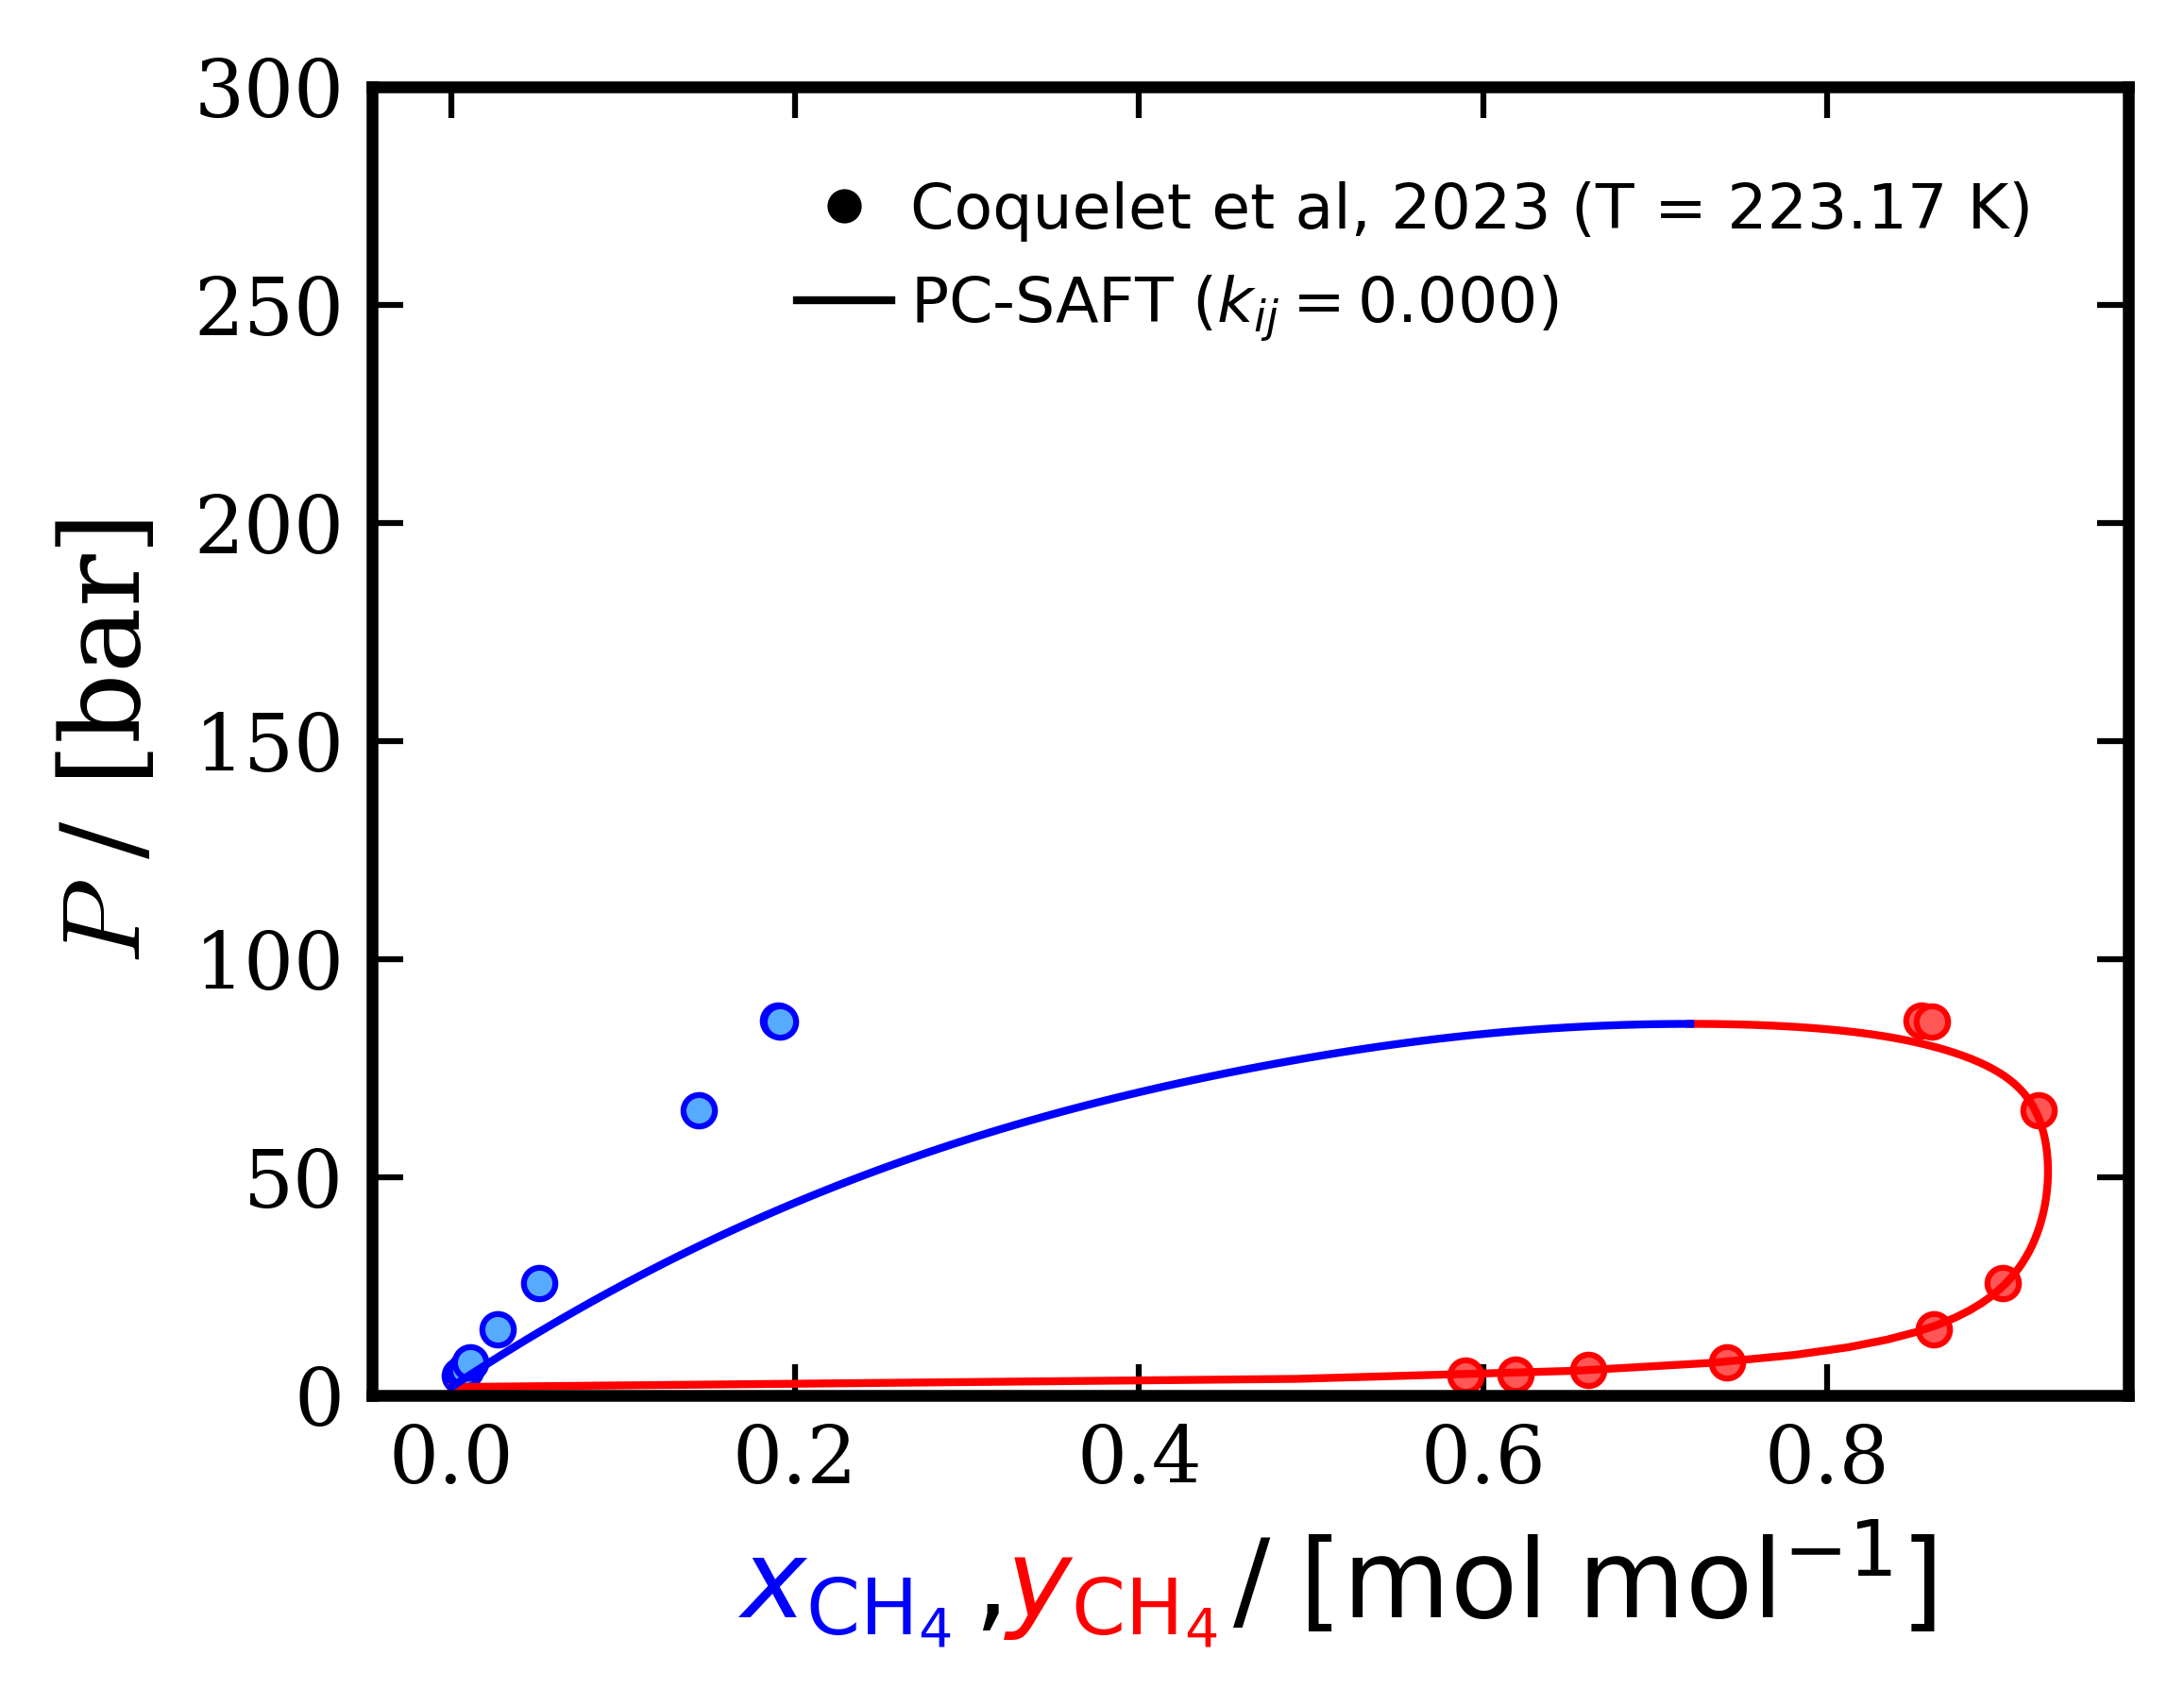

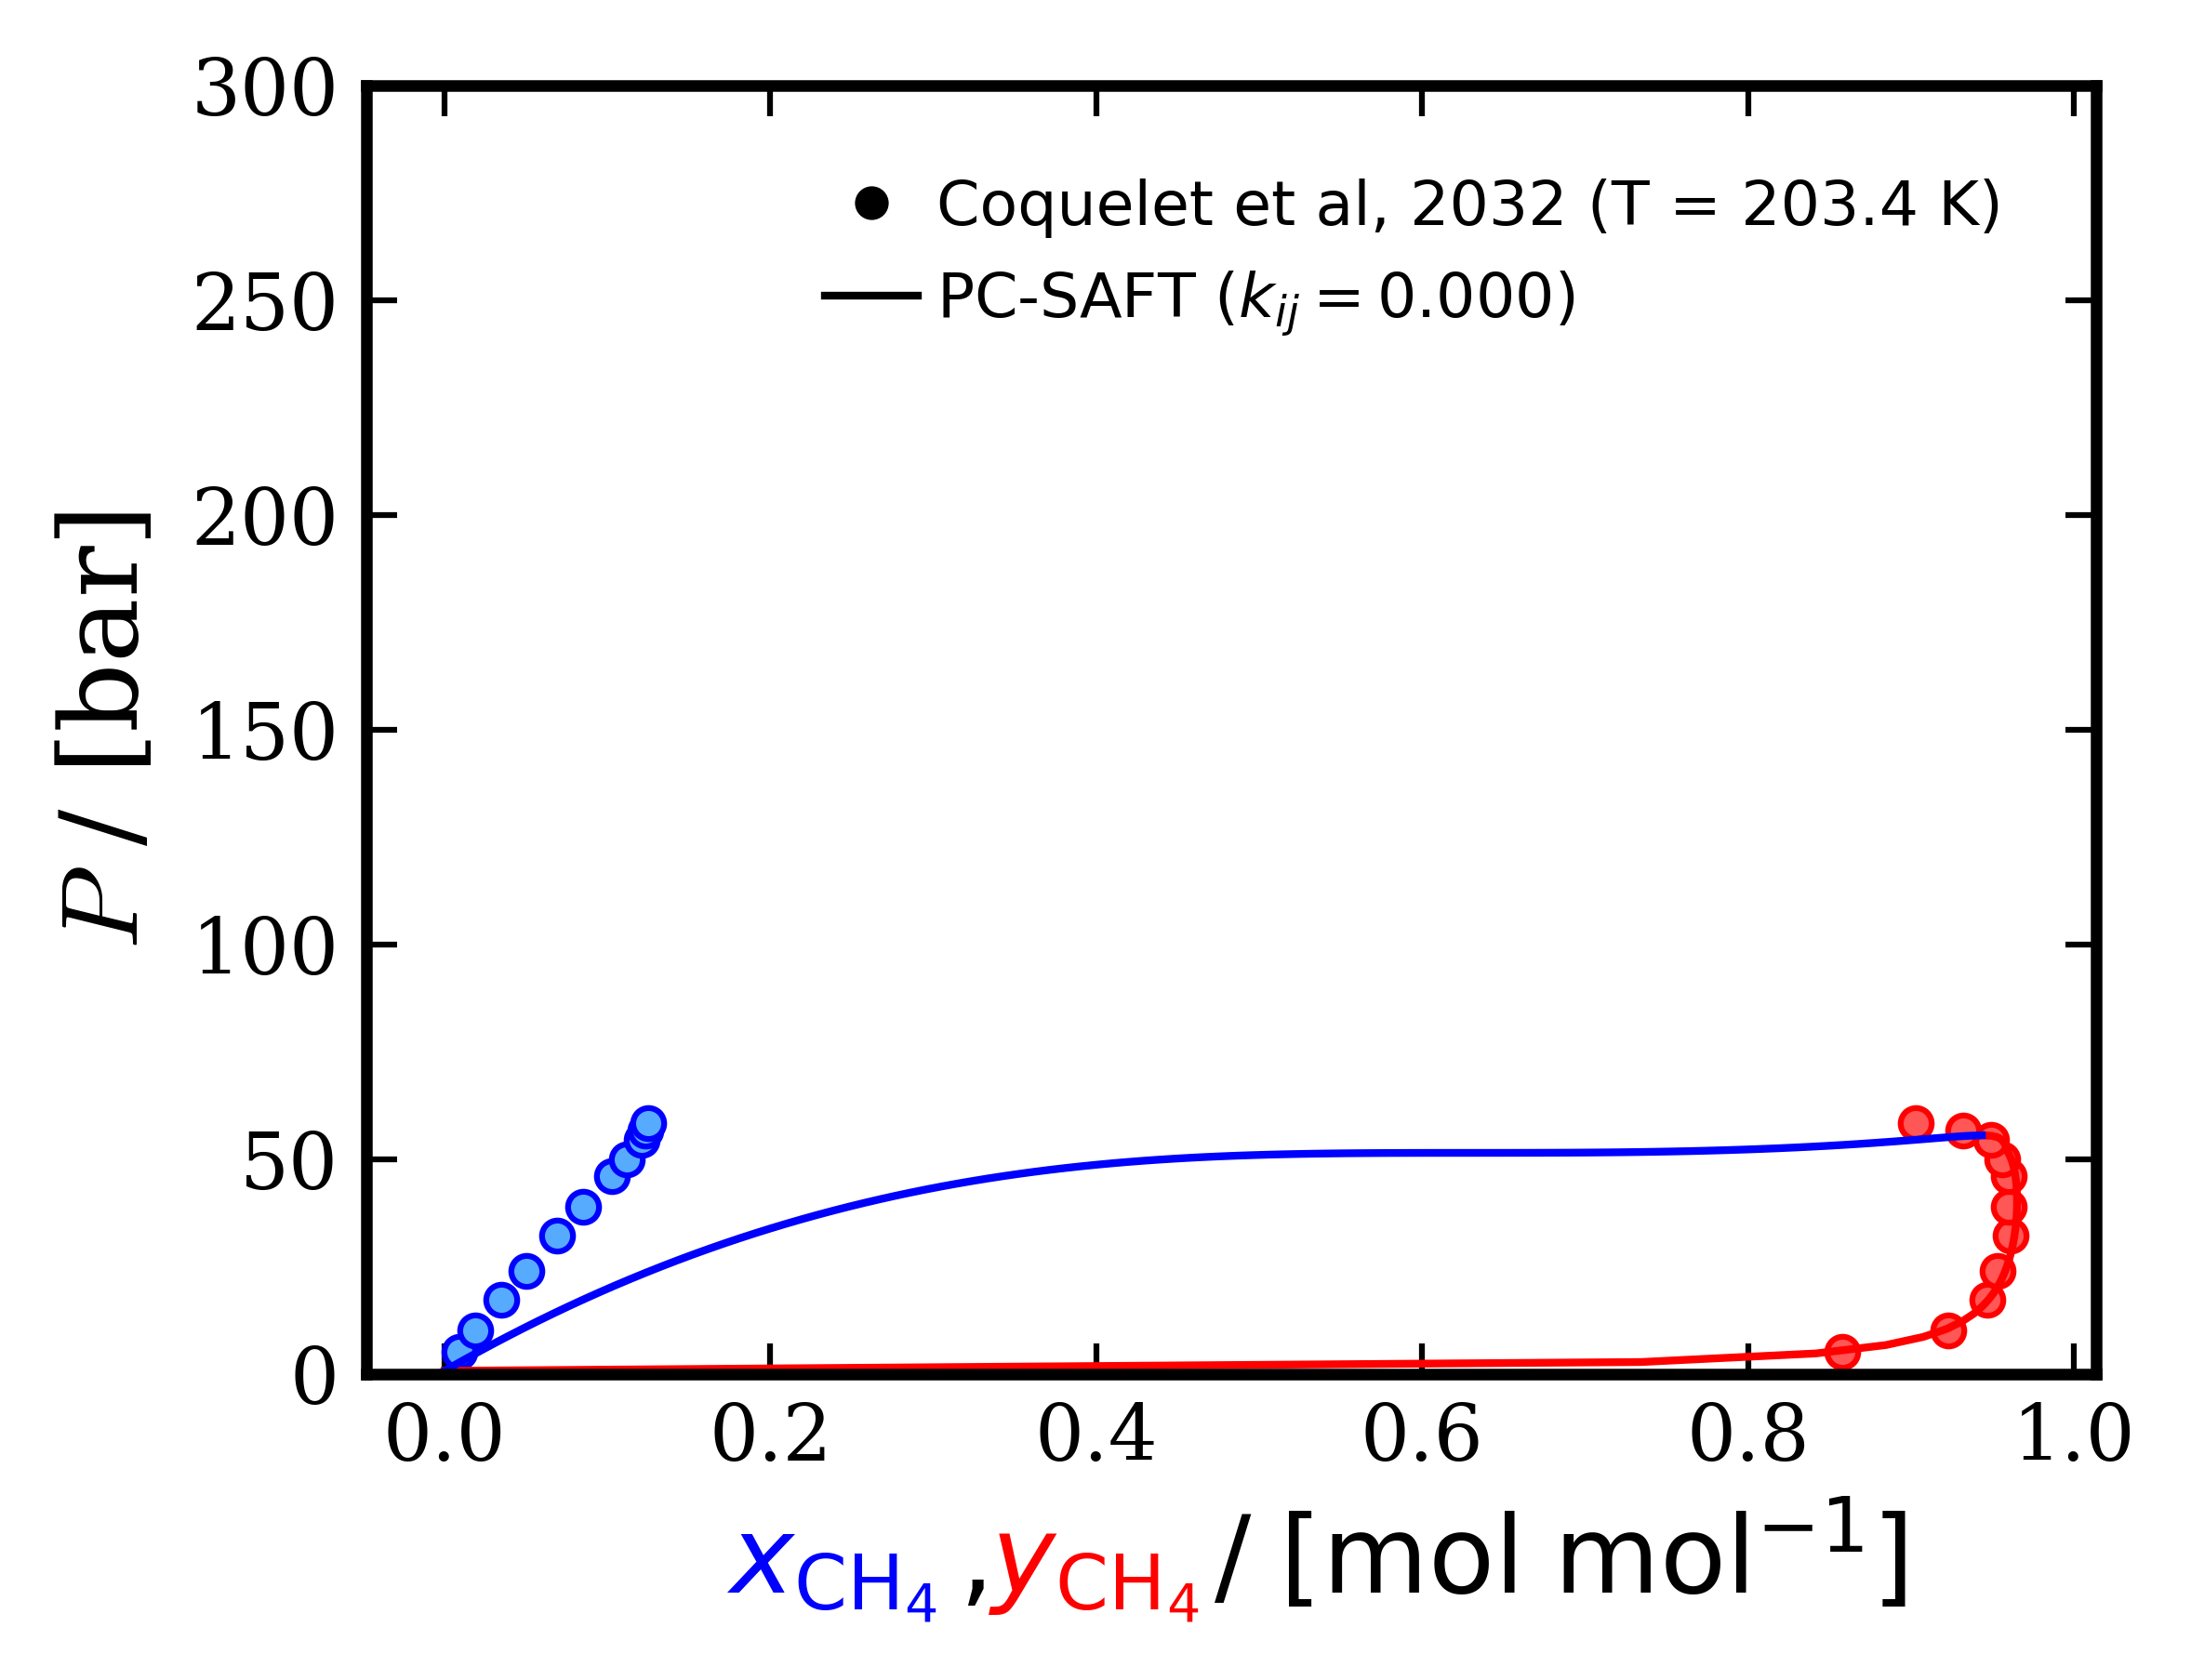

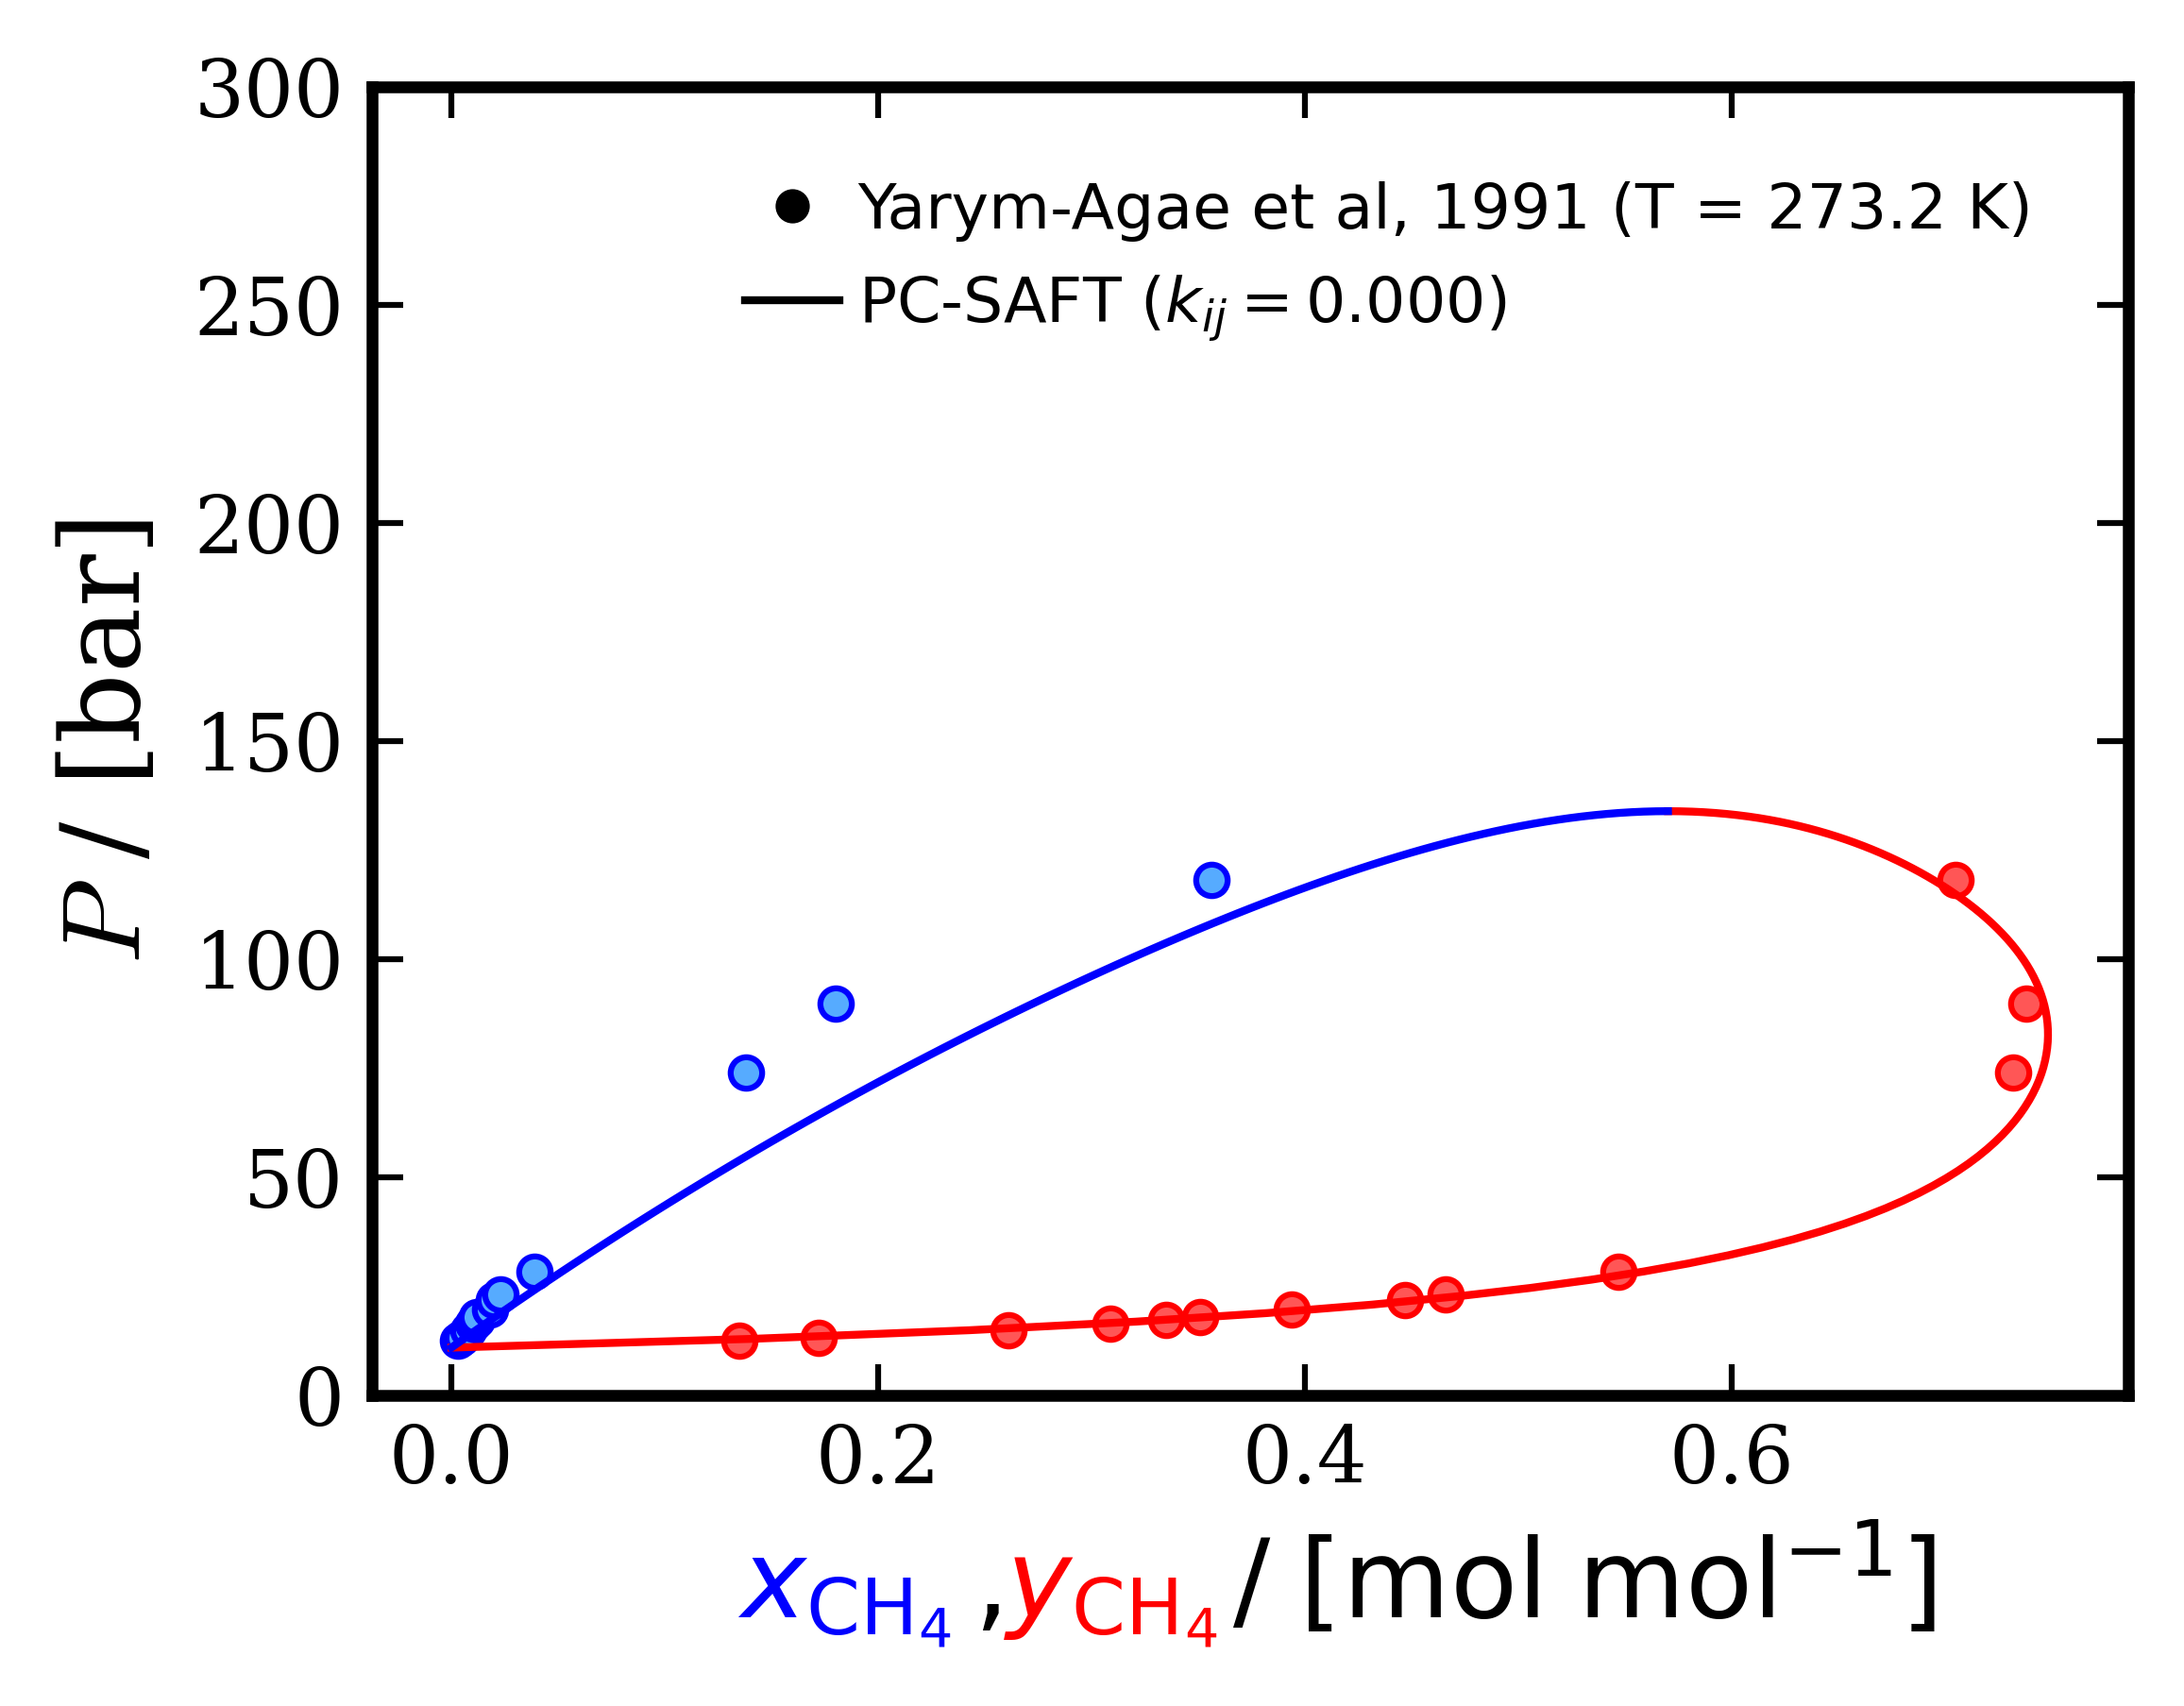

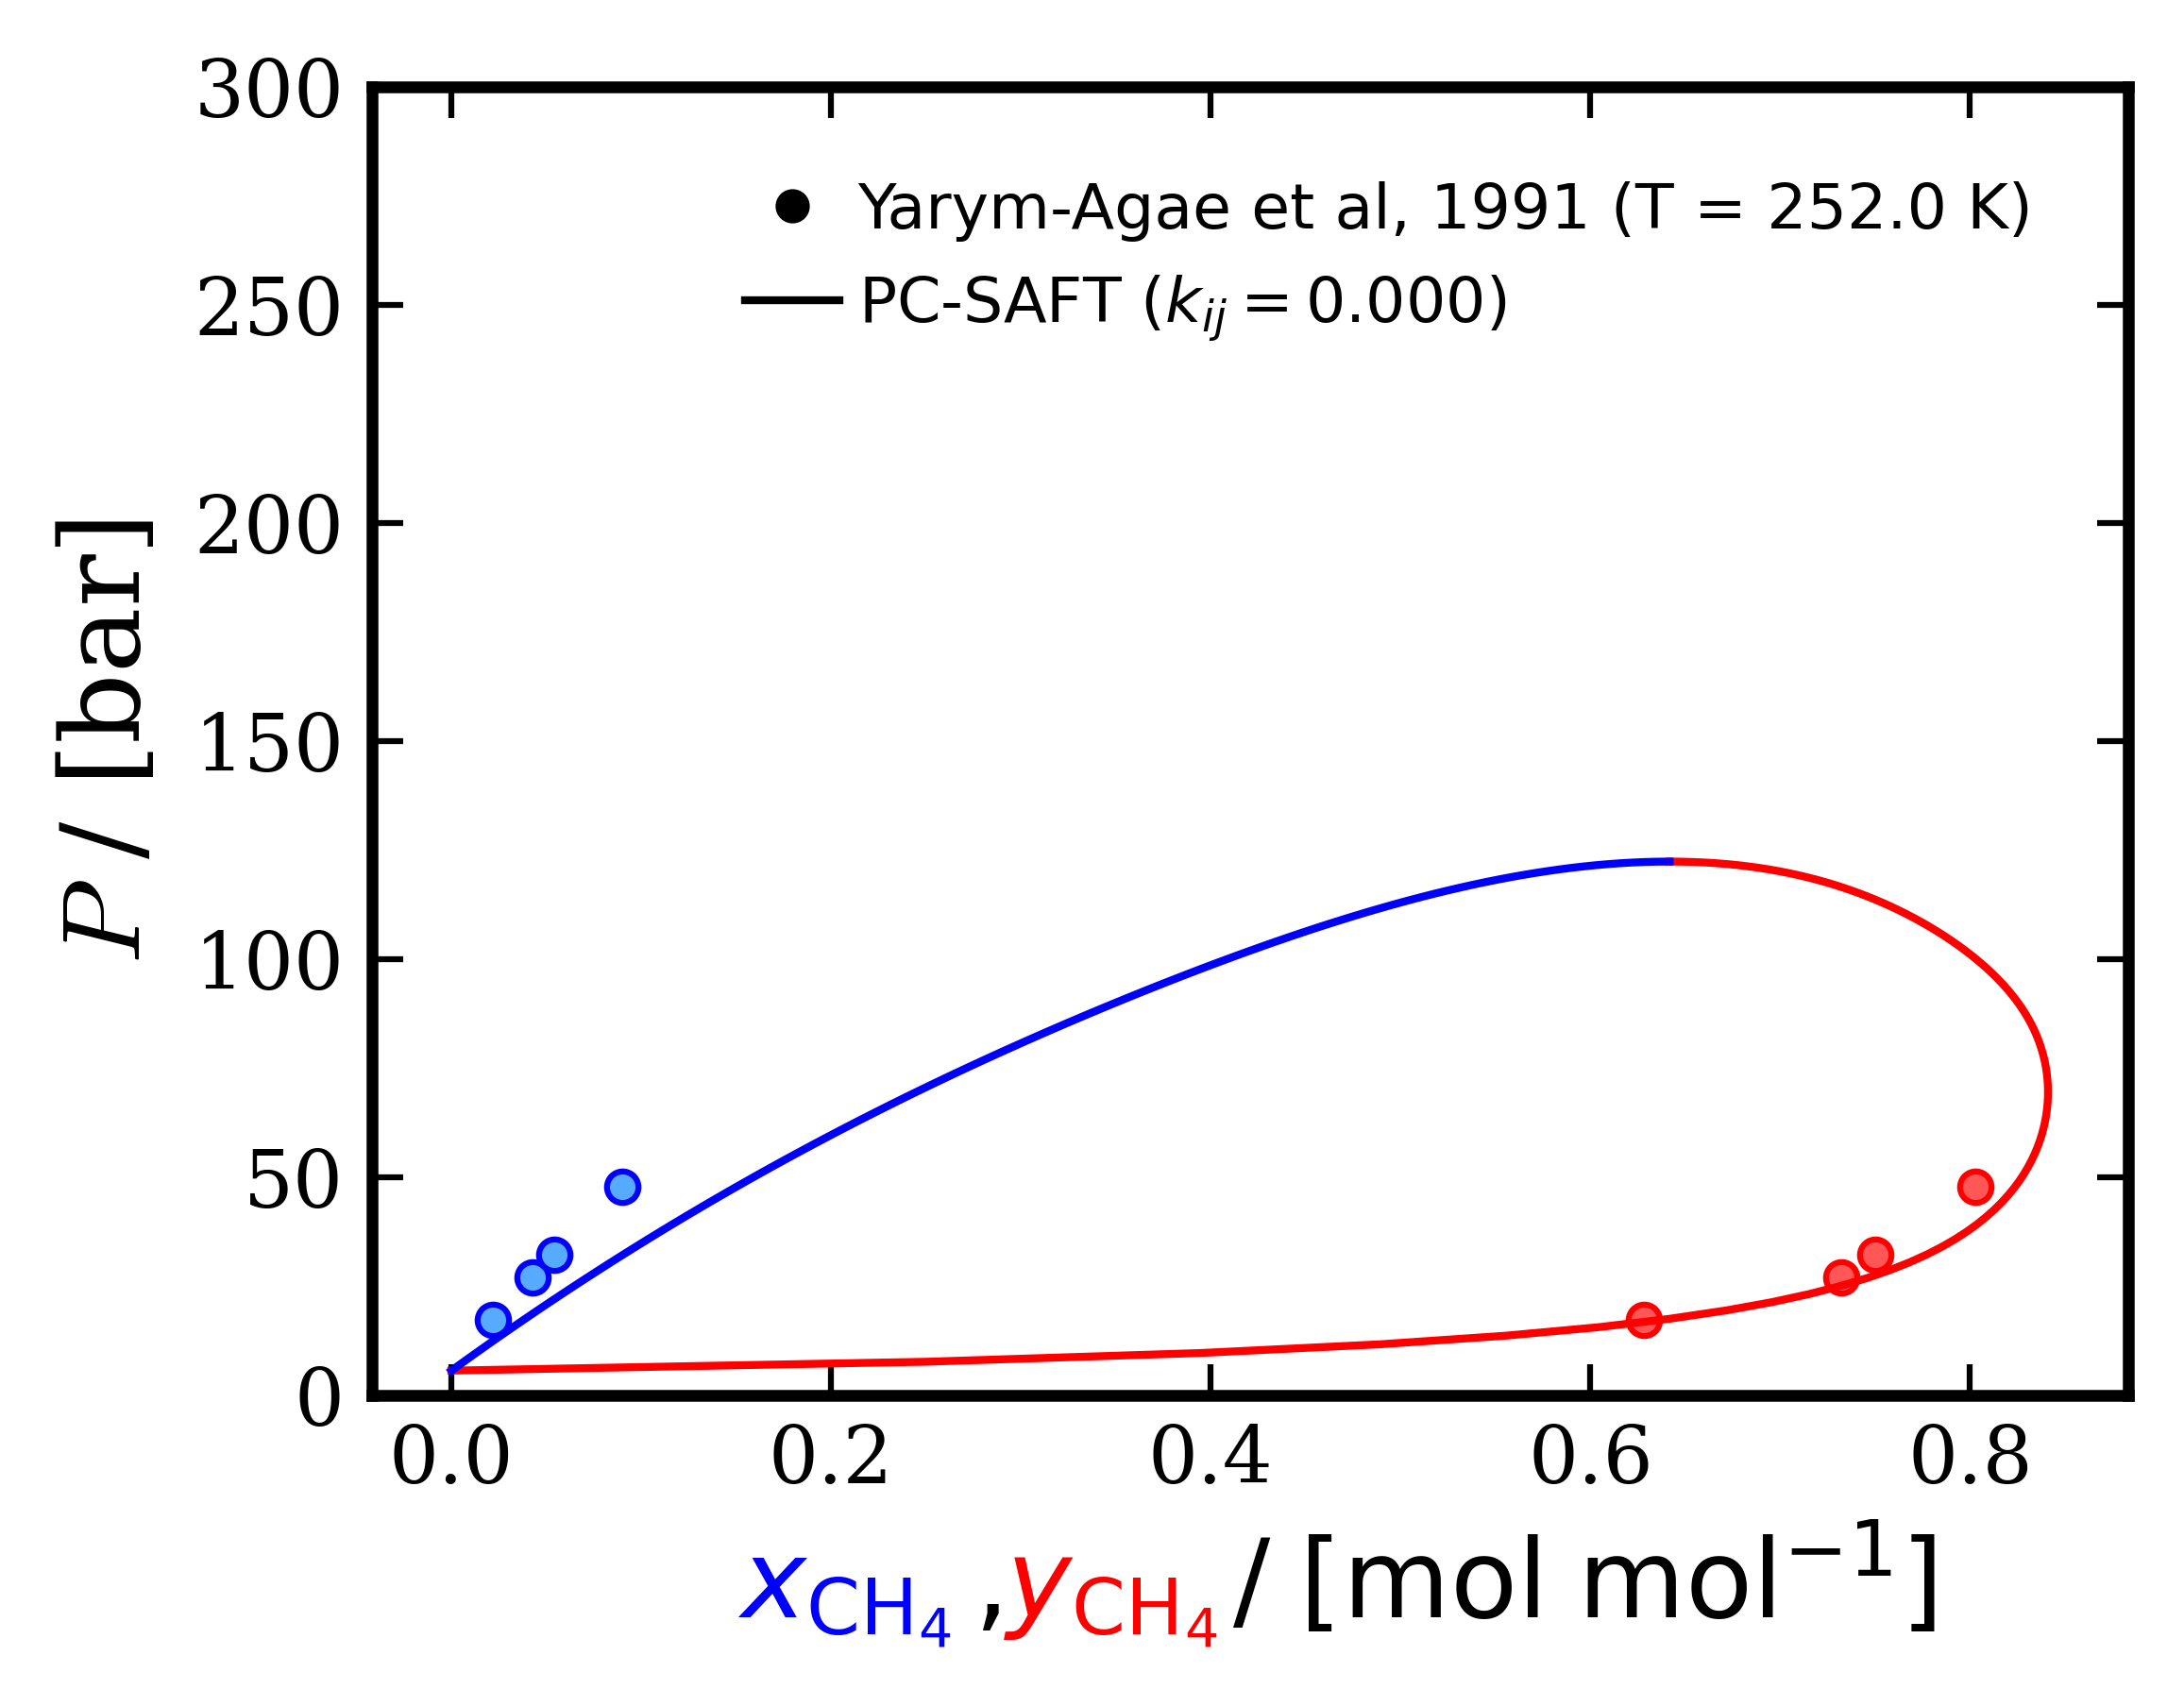

In [7]:
if PLOT == True:
    for T in data[cols["T"]].unique():
        VLE_PLOT(mixture, data, cols, T, 0)
        plt.show()

In [8]:
kij_distance    = []

for T in data[cols["T"]].unique():

    isotherm = data[data[cols["T"]] == T]

    if isotherm[cols['Comp']].iloc[0] == comp2:
        x = isotherm[cols["x1"]].to_numpy(float)
        y = isotherm[cols["y1"]].to_numpy(float)
    else:
        x = 1 - isotherm[cols["x1"]].to_numpy(float)
        y = 1 - isotherm[cols["y1"]].to_numpy(float)

    ds, method  = make_dataset(T, isotherm, x, y)
    estimator   = Estimator([ds], weights=[1], losses=[Loss.linear()])

    res = optimize_kij_multistart(estimator)

    if res is not None:
        fitted_kij  = float(np.atleast_1d(res.x)[0])
        mard        = float(np.atleast_1d(
                        estimator.mean_absolute_relative_difference(eos_from_kij(res.x)) * 100
                      ).mean())
        kij_distance.append(fitted_kij)
    else:
        fitted_kij  = np.nan
        mard        = np.nan
        kij_distance.append(np.nan)

    print(f"T = {T:8.4f} K | {method:15s} | kij = {fitted_kij:+.6f} | MARD = {mard:.4f} %")

    kij_file = os.path.join("PLOTS", "kij_all.csv")
    write_header = not os.path.exists(kij_file)
    with open(kij_file, "a", newline="") as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(["Optimization type", "Temperature_[K]", "kij", "MARD_percentage"])
        writer.writerow(["distance", T, fitted_kij, mard])


T = 223.1700 K | phase_diagram   | kij = +nan | MARD = nan %
T = 203.4000 K | phase_diagram   | kij = +0.068232 | MARD = 0.6413 %
T = 273.2000 K | phase_diagram   | kij = +0.025852 | MARD = 0.6210 %
T = 252.0000 K | phase_diagram   | kij = +0.050601 | MARD = 0.4660 %


Skipping T = 223.17 K (optimization failed)


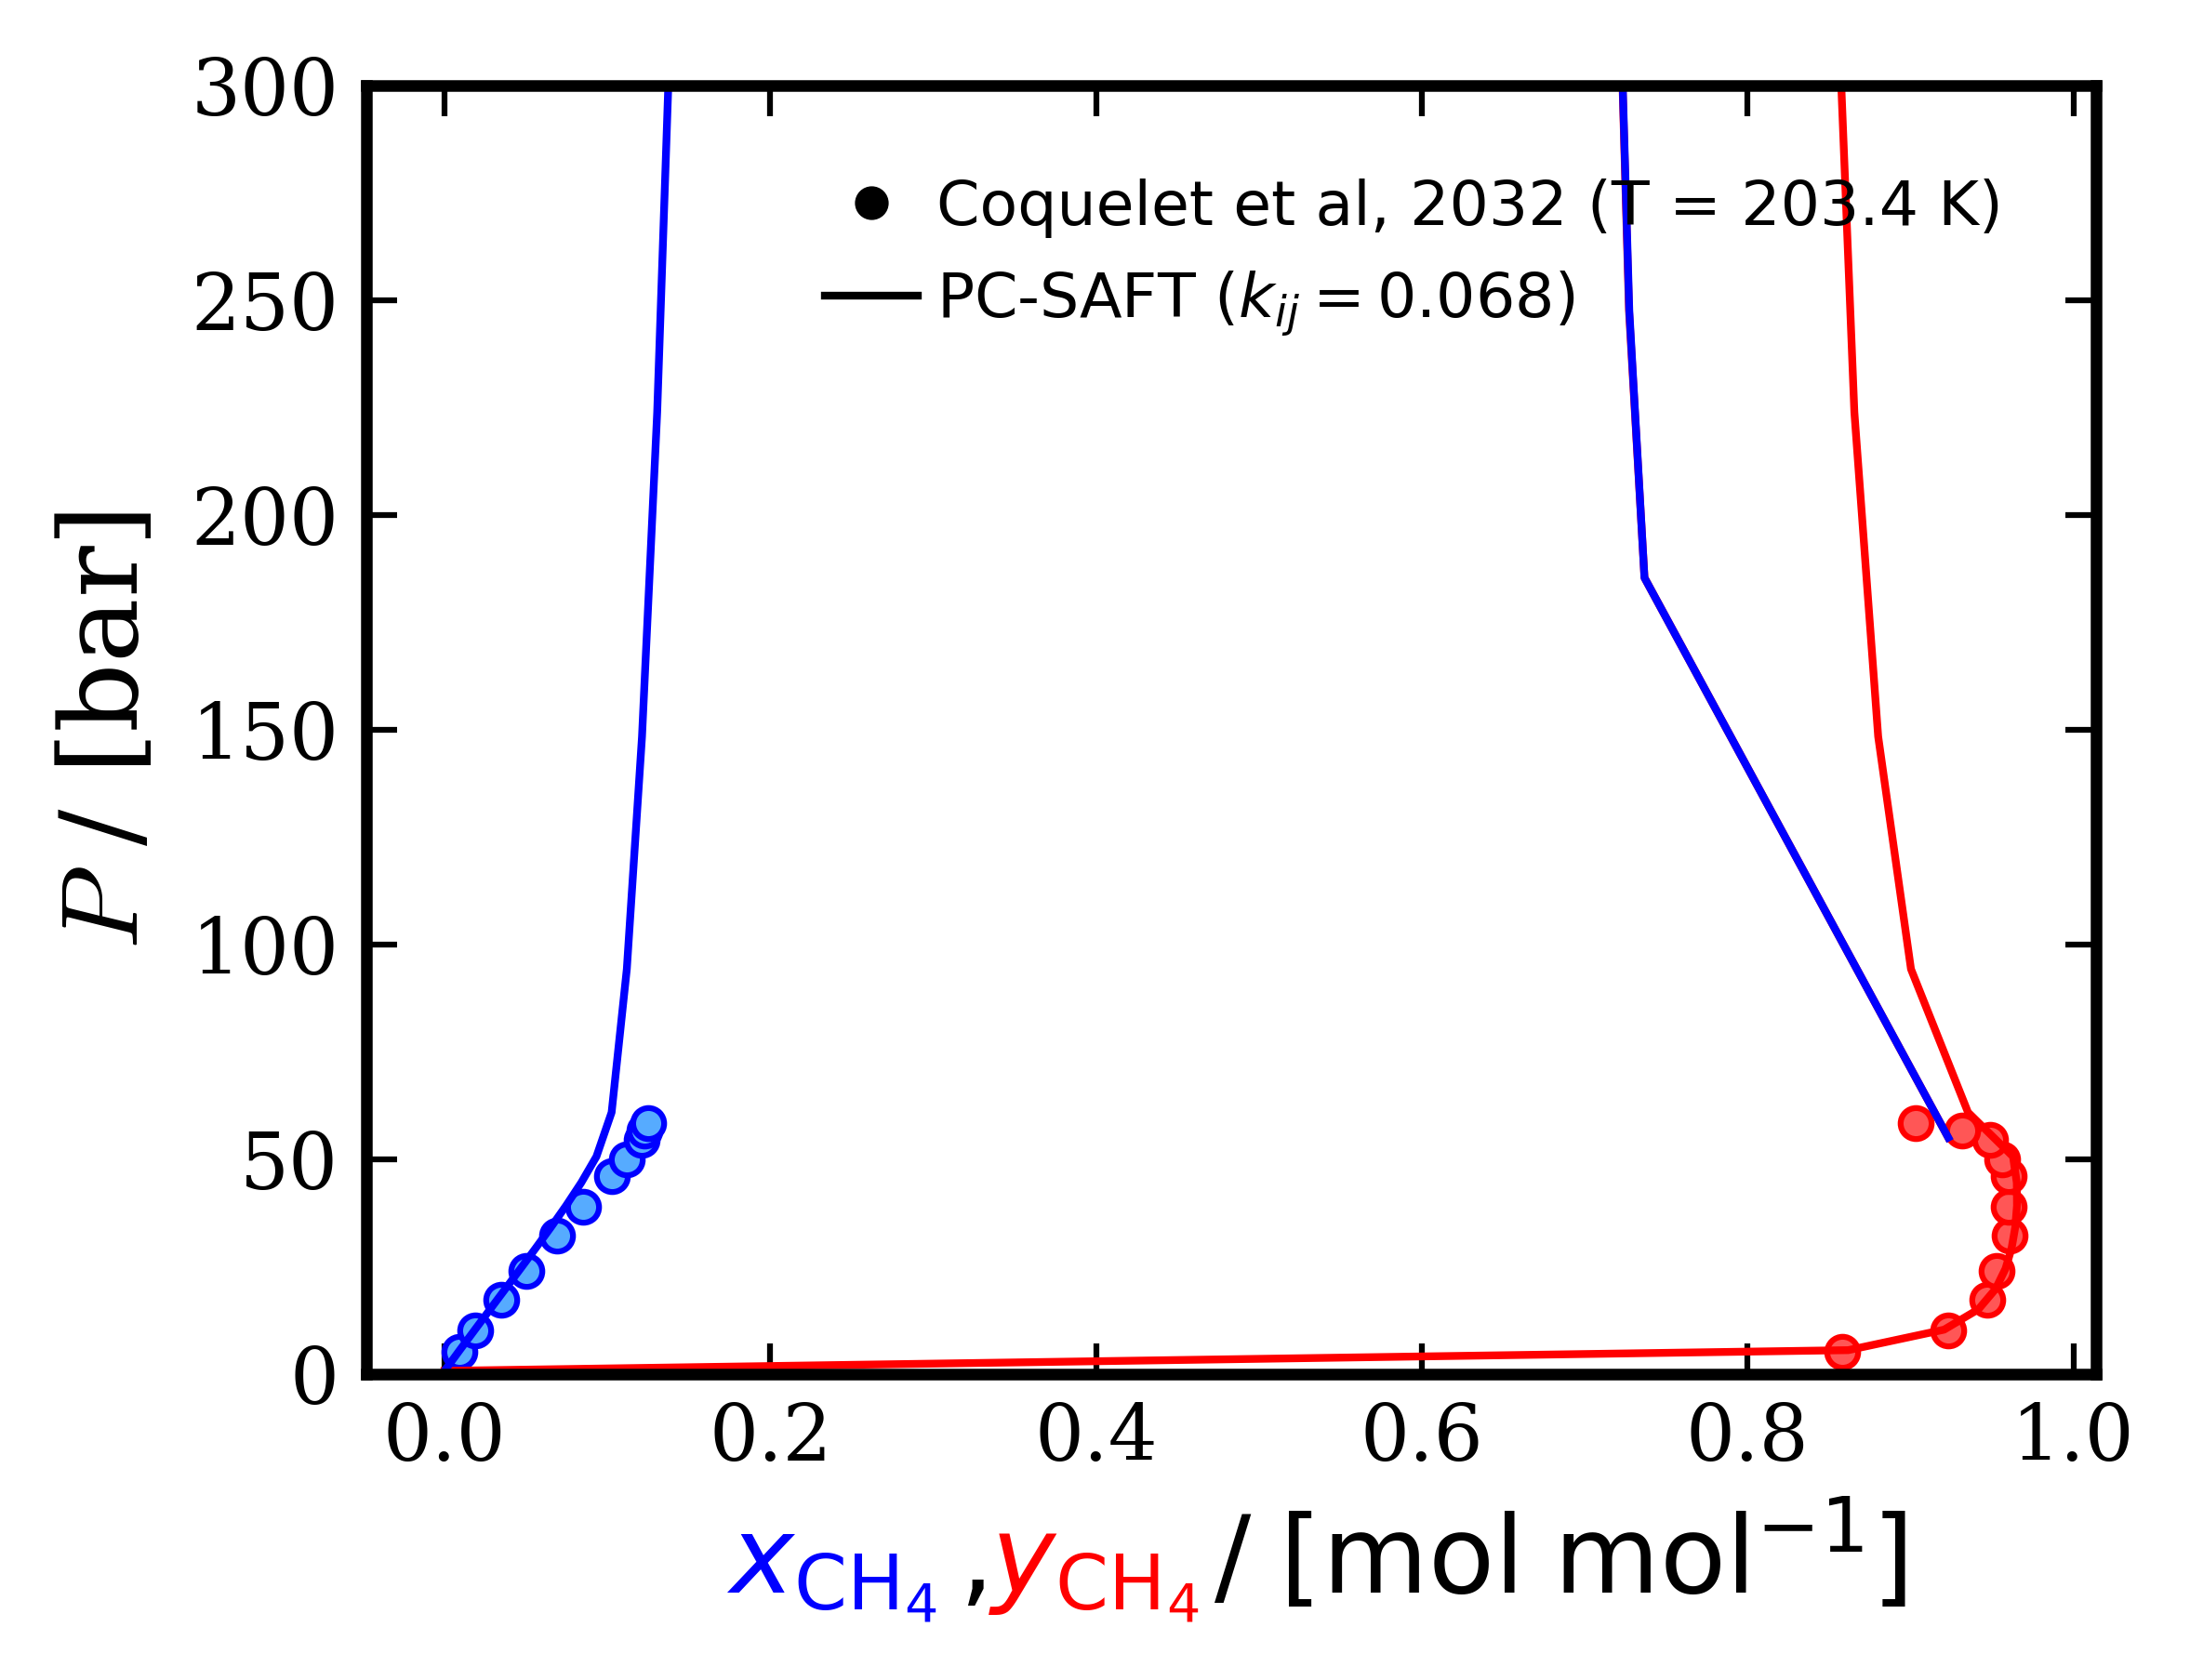

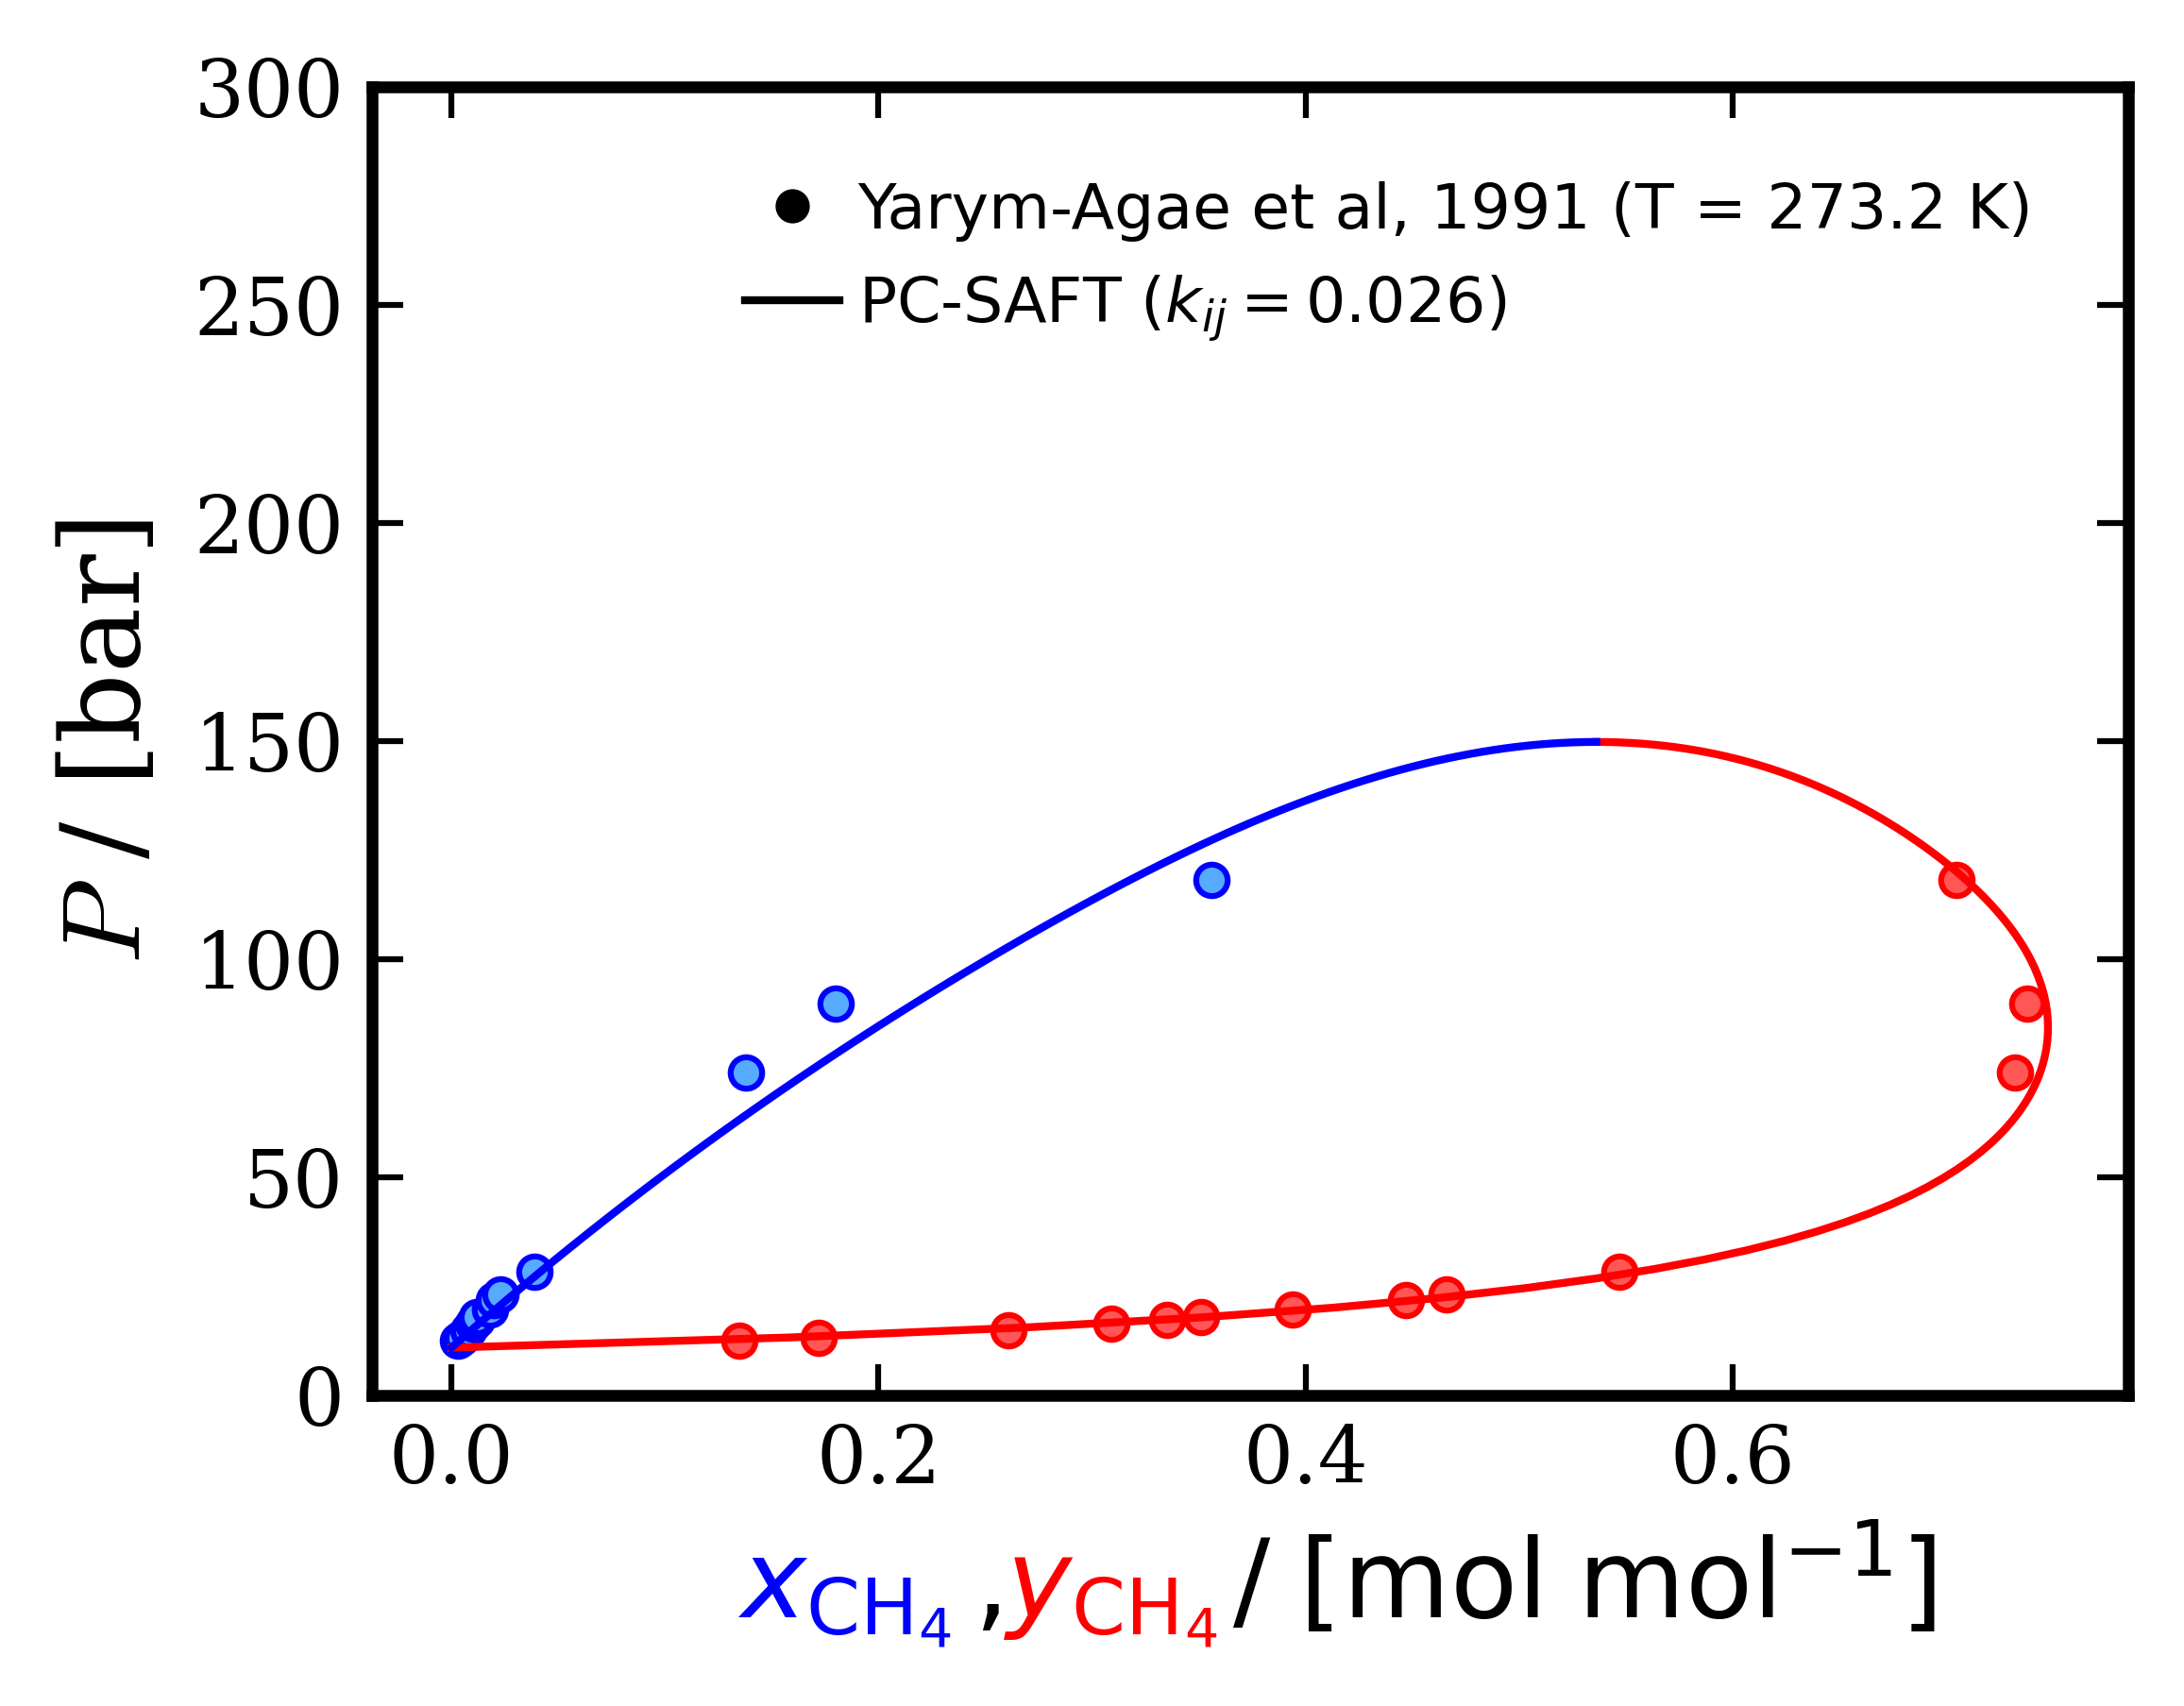

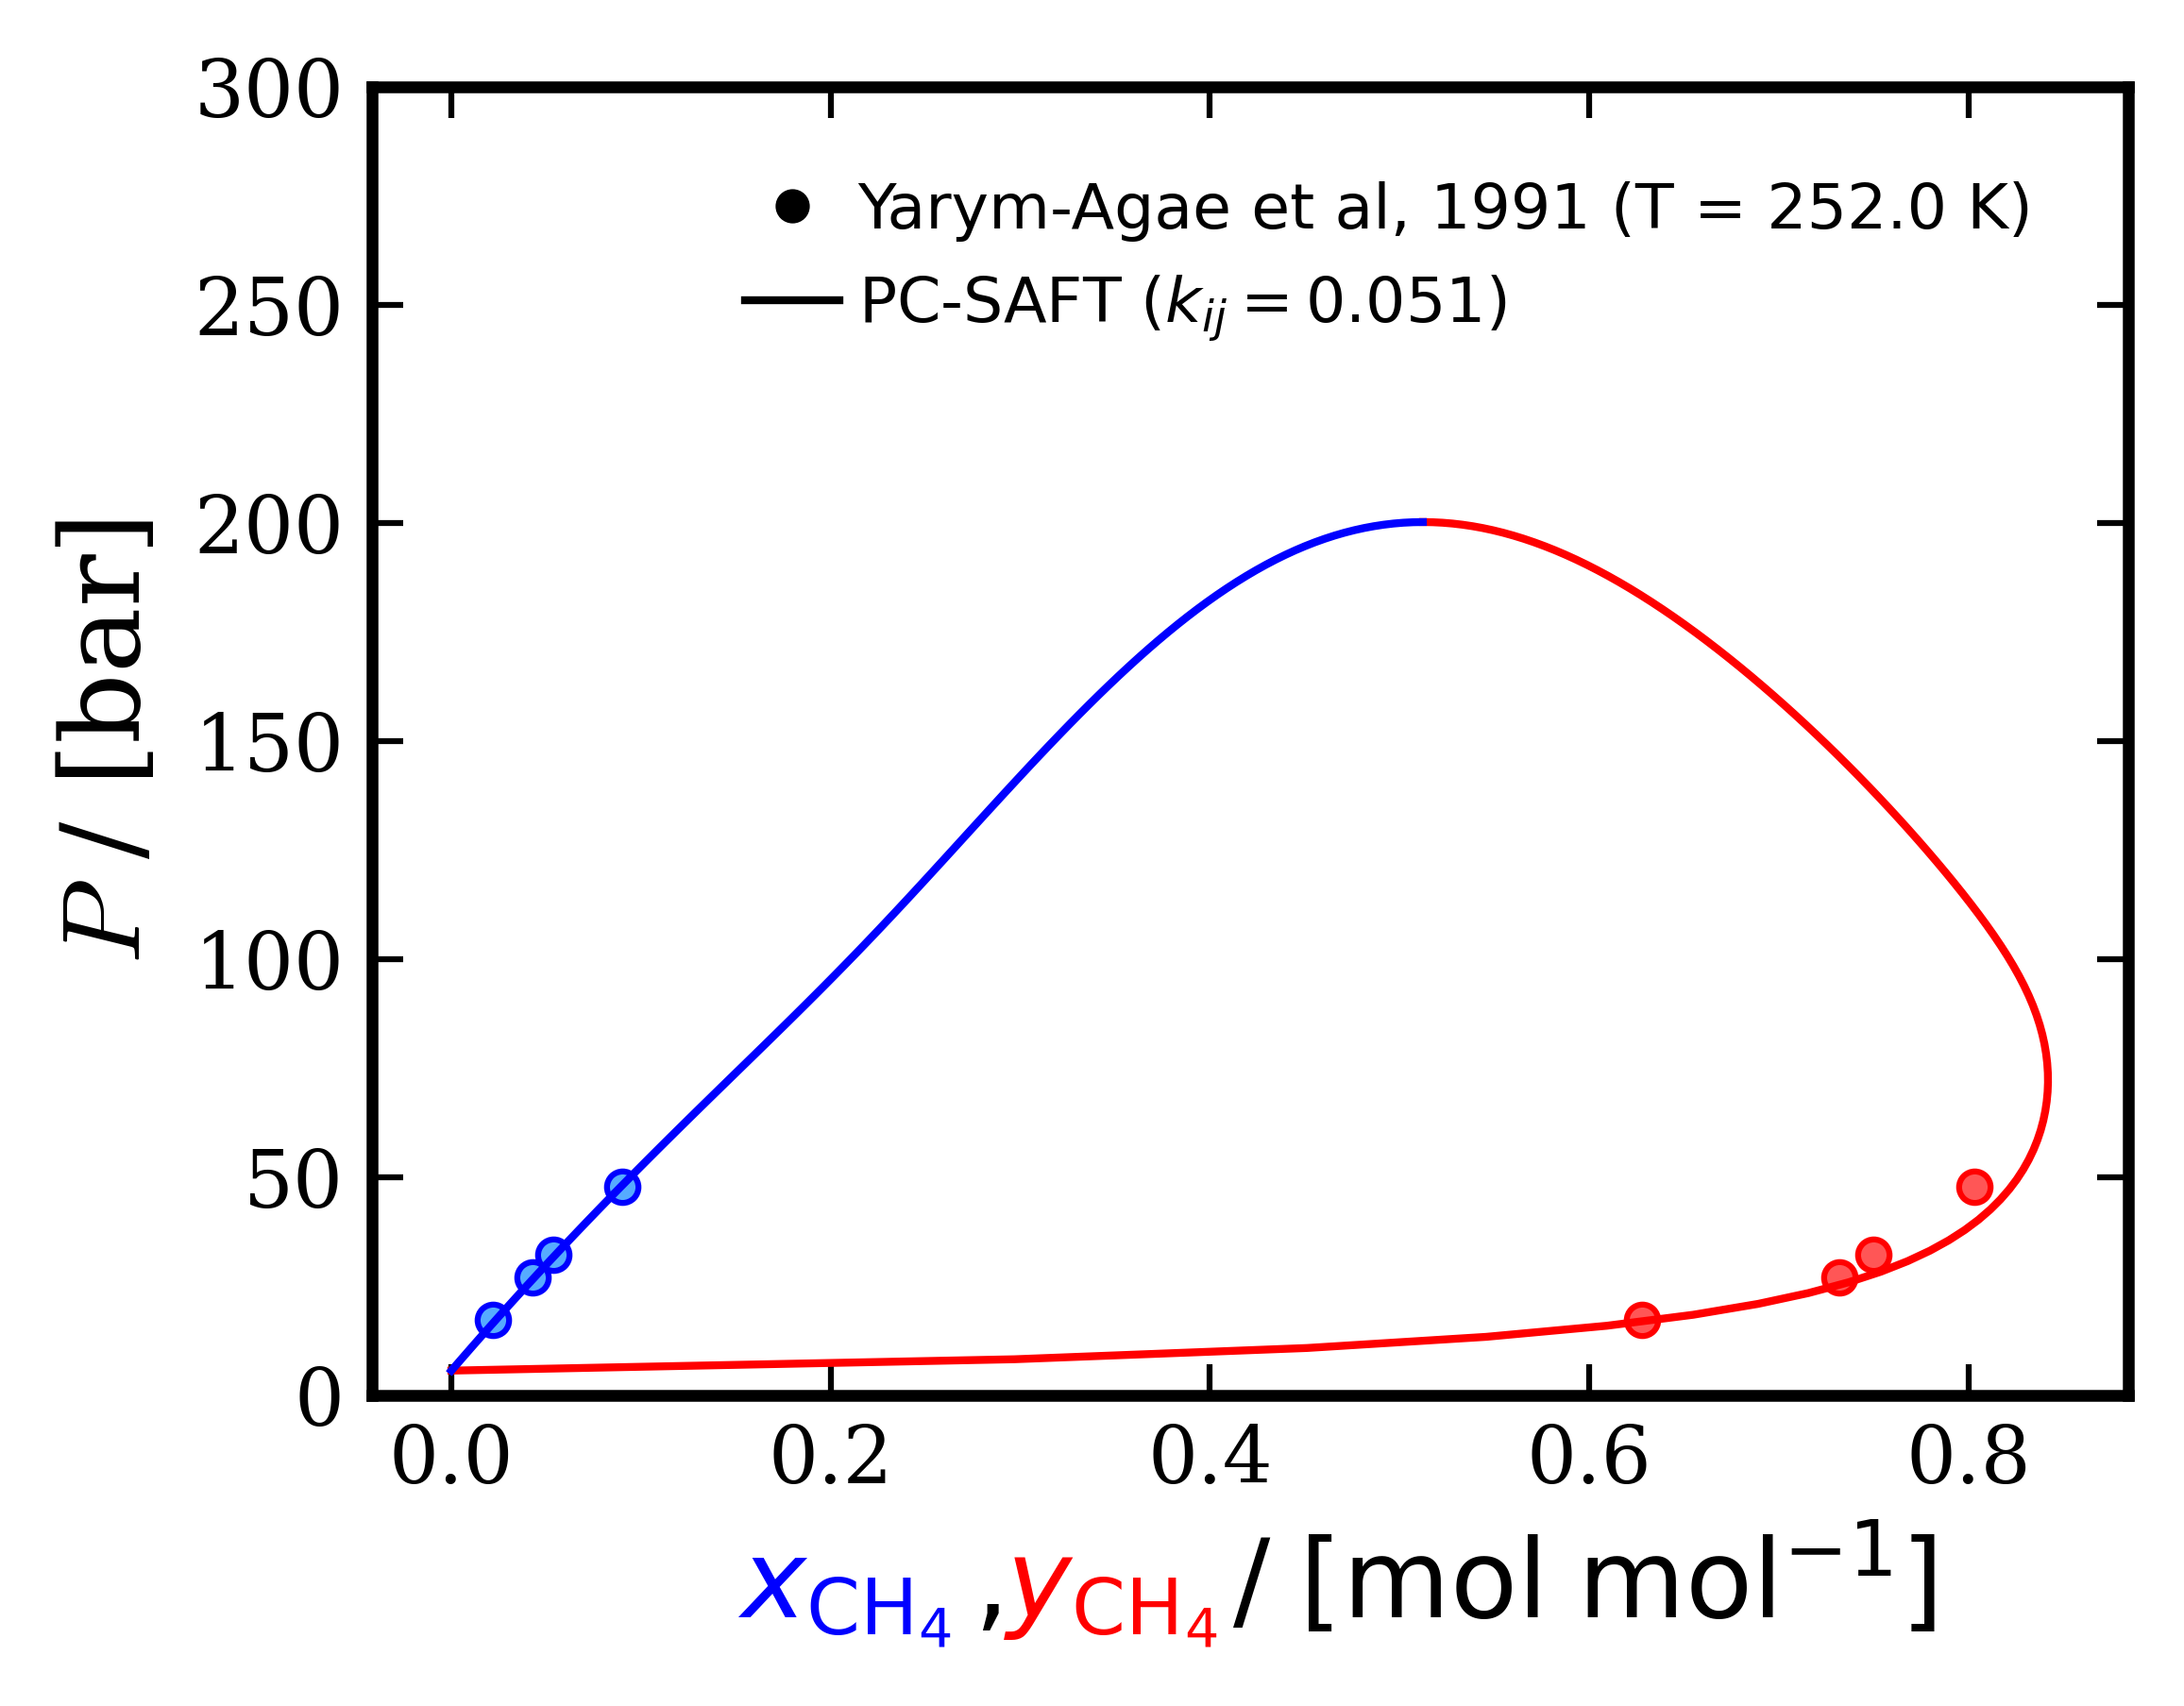

In [9]:
if PLOT == True:
    for T, kij in zip(data[cols["T"]].unique(), kij_distance):
        if np.isnan(kij):
            print(f"Skipping T = {T} K (optimization failed)")
            continue
        VLE_PLOT(mixture, data, cols, T, kij)
        plt.show()


In [10]:
kij_mu = []

for T in data[cols["T"]].unique():

    isotherm = data[data[cols["T"]] == T]

    if cols['Comp'] in isotherm.columns:
        if isotherm[cols['Comp']].iloc[0] == comp2:
            x = isotherm[cols["x1"]].to_numpy(float)
            y = isotherm[cols["y1"]].to_numpy(float)
        else:
            x = 1 - isotherm[cols["x1"]].to_numpy(float)
            y = 1 - isotherm[cols["y1"]].to_numpy(float)

    ds           = DataSet.binary_vle_chemical_potential(
                       np.full(len(isotherm), T) * KELVIN,
                       isotherm[cols["P"]].values * BAR, x, y)
    estimator_mu = Estimator([ds], weights=[1], losses=[Loss.linear()])

    try:
        res          = optimize_kij_multistart(estimator_mu)
        if res is None:
            raise RuntimeError("All starting points failed")

        fitted_kij_mu = float(np.atleast_1d(res.x)[0])
        mard_mu       = float(np.atleast_1d(
                          estimator_mu.mean_absolute_relative_difference(
                              eos_from_kij(res.x)) * 100).mean())
        kij_mu.append(fitted_kij_mu)

    except Exception as e:
        print(f"kij_mu failed at T = {T} K: {e}")
        fitted_kij_mu = np.nan
        mard_mu       = np.nan
        kij_mu.append(np.nan)

    kij_file = os.path.join("PLOTS", "kij_all.csv")
    write_header = not os.path.exists(kij_file)
    with open(kij_file, "a", newline="") as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(["Optimization type", "Temperature_[K]", "kij", "MARD_percentage"])
        writer.writerow(["chemical potential", T, fitted_kij_mu, mard_mu])

    print(f"T = {T:8.4f} K | kij_mu = {fitted_kij_mu:+.6f} | MARD = {mard_mu:.4f} %")


T = 223.1700 K | kij_mu = +0.056197 | MARD = 2.1354 %
T = 203.4000 K | kij_mu = +0.057885 | MARD = 2.5179 %
T = 273.2000 K | kij_mu = +0.052109 | MARD = 2.3450 %
T = 252.0000 K | kij_mu = +0.050266 | MARD = 2.1834 %


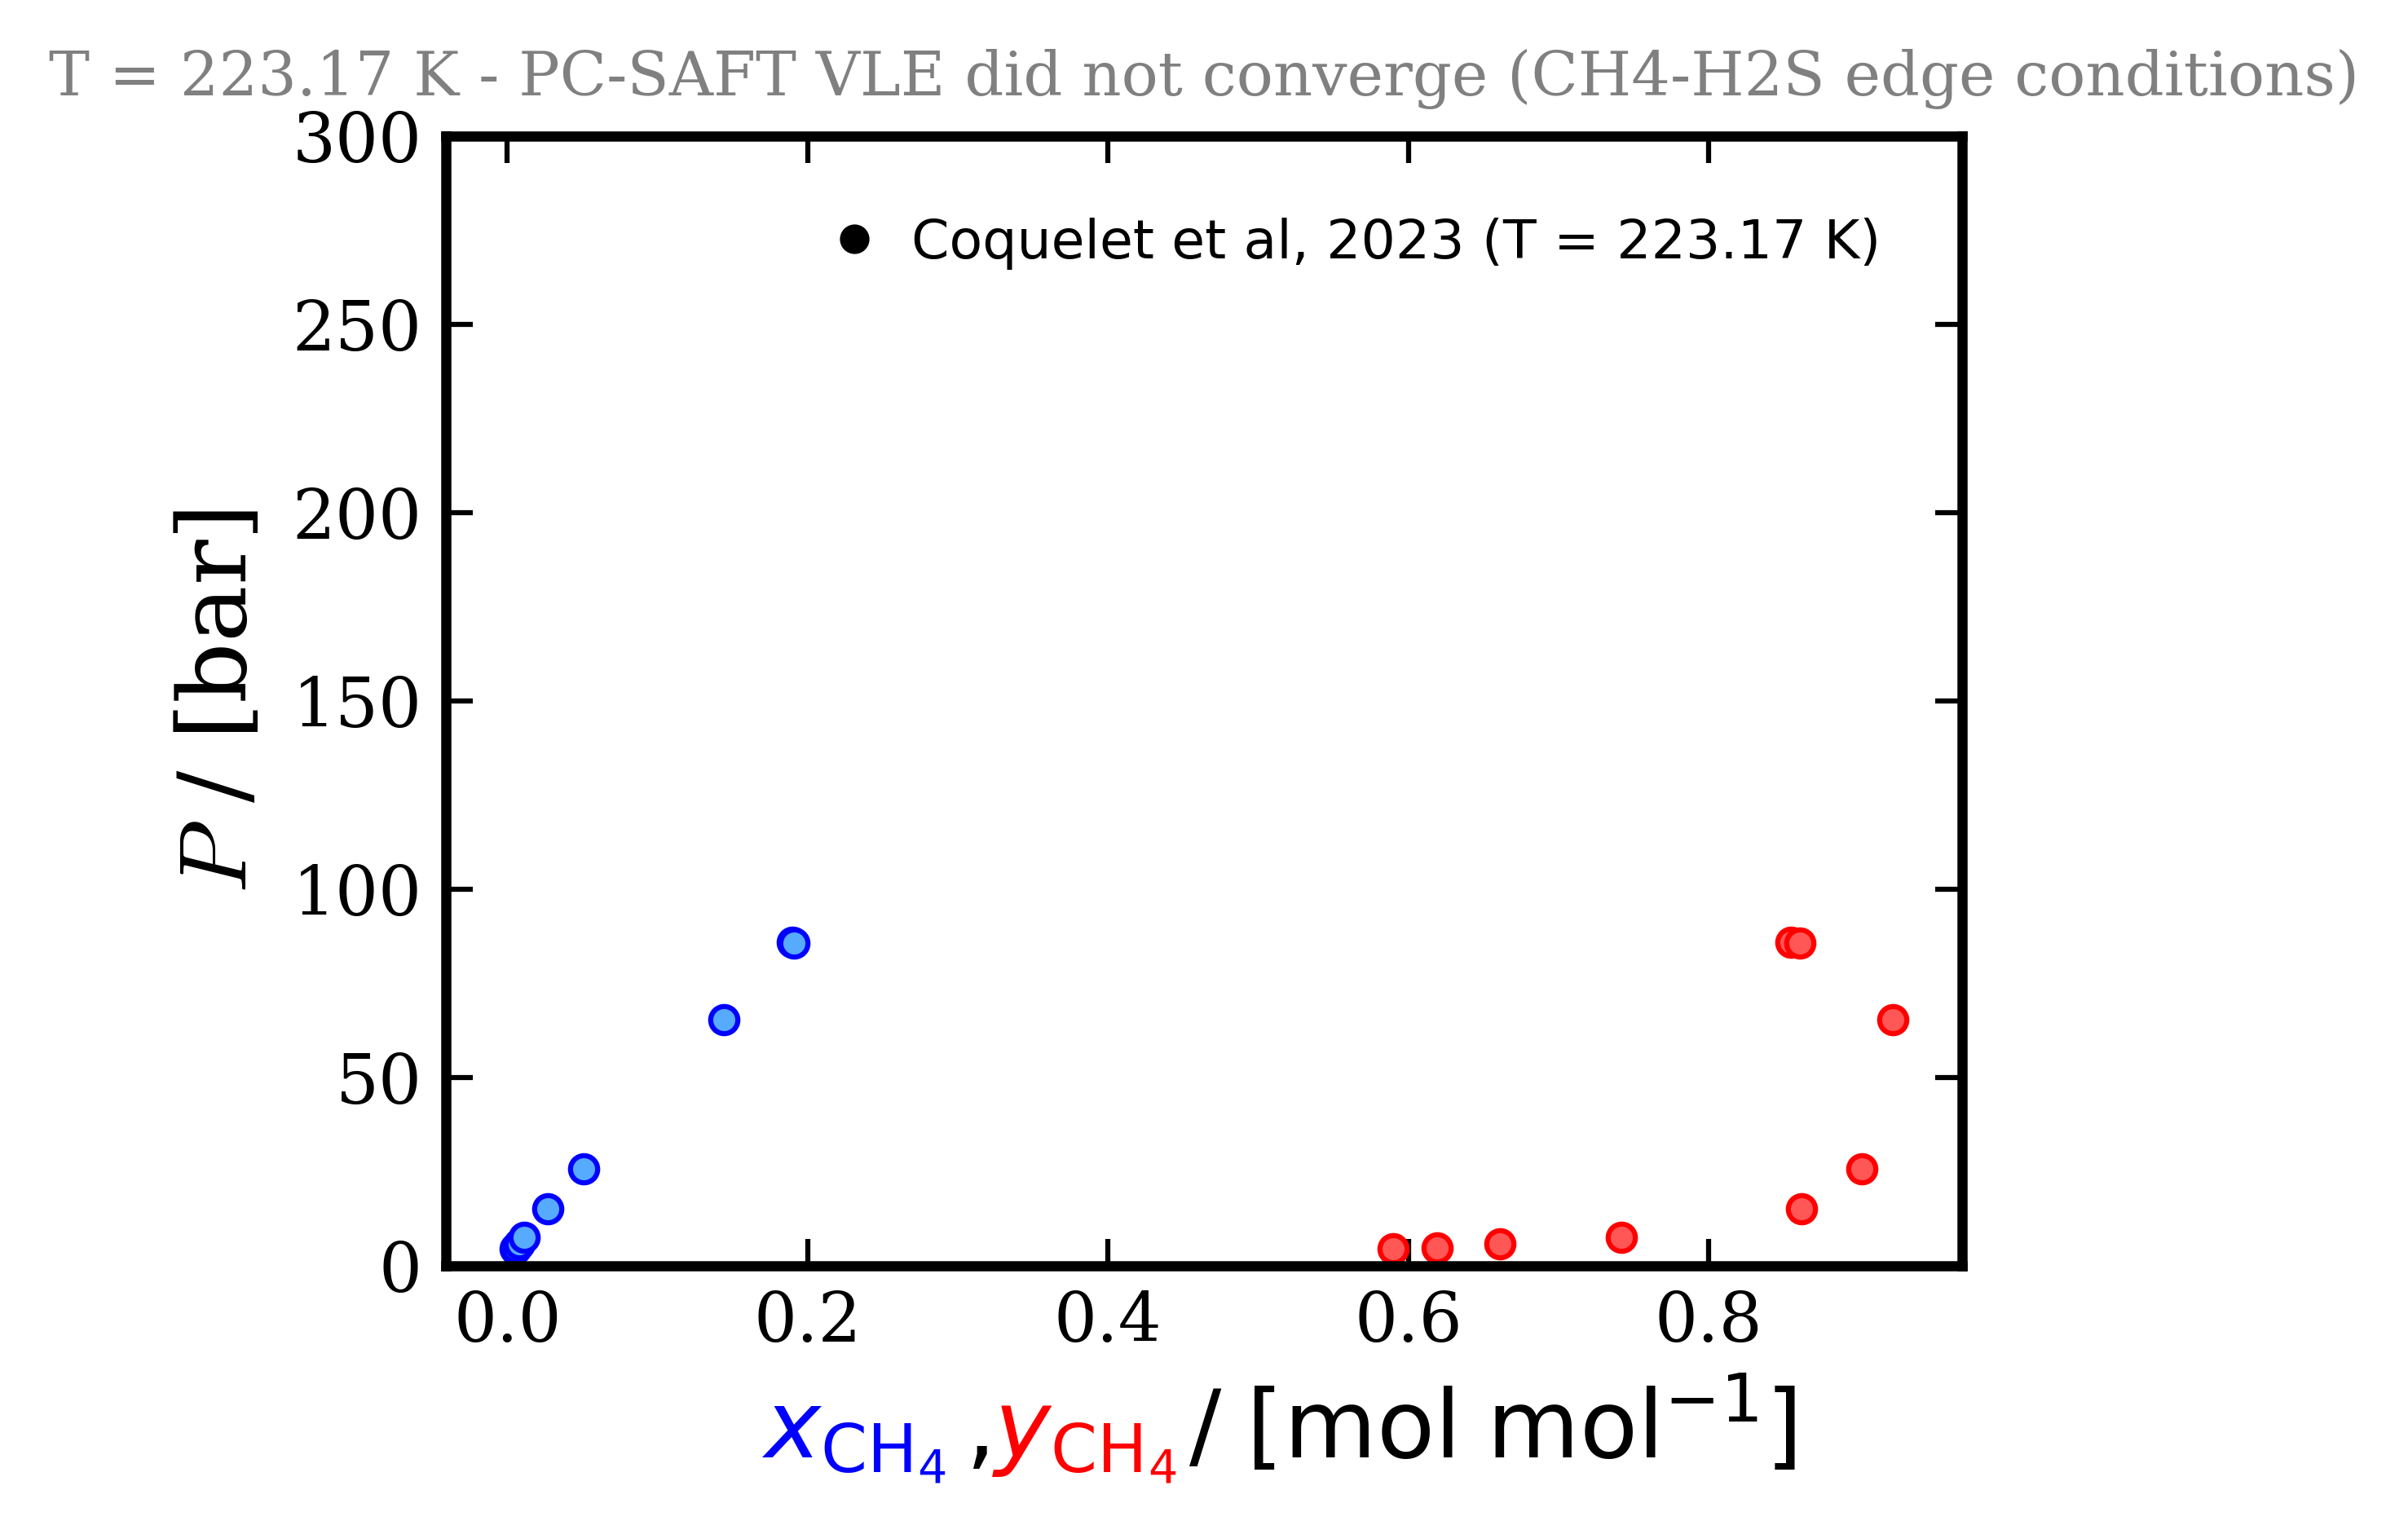

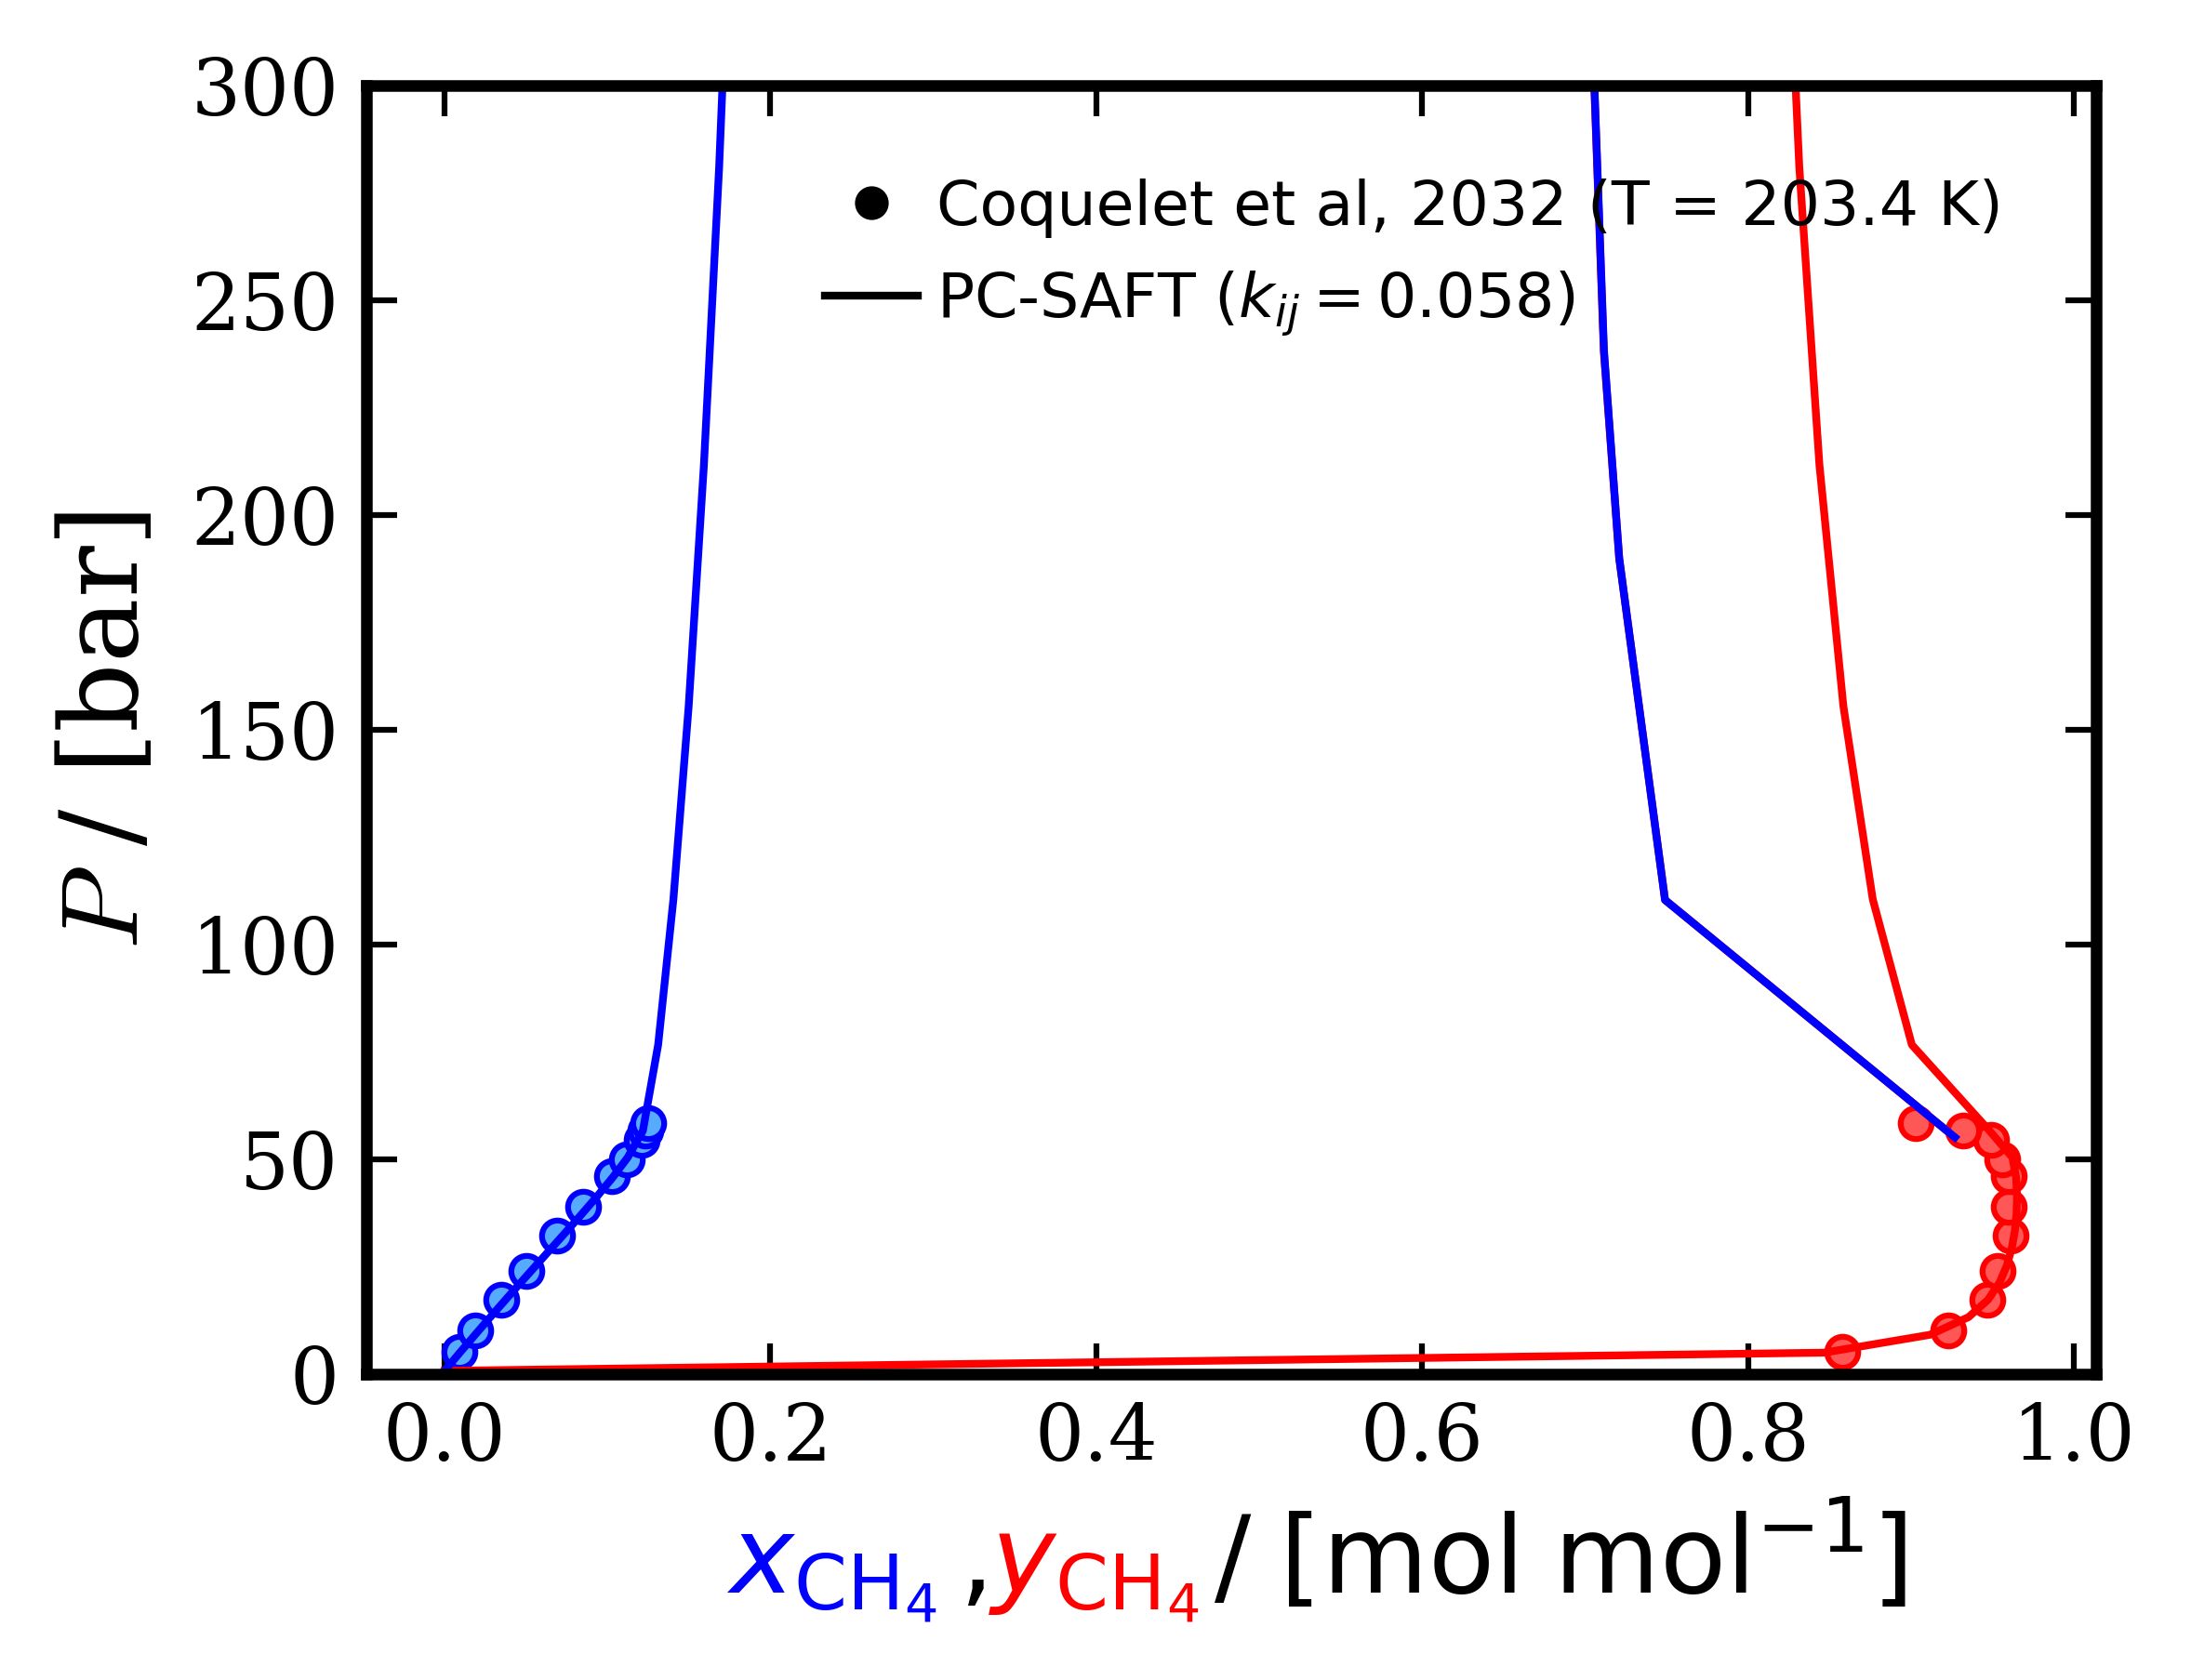

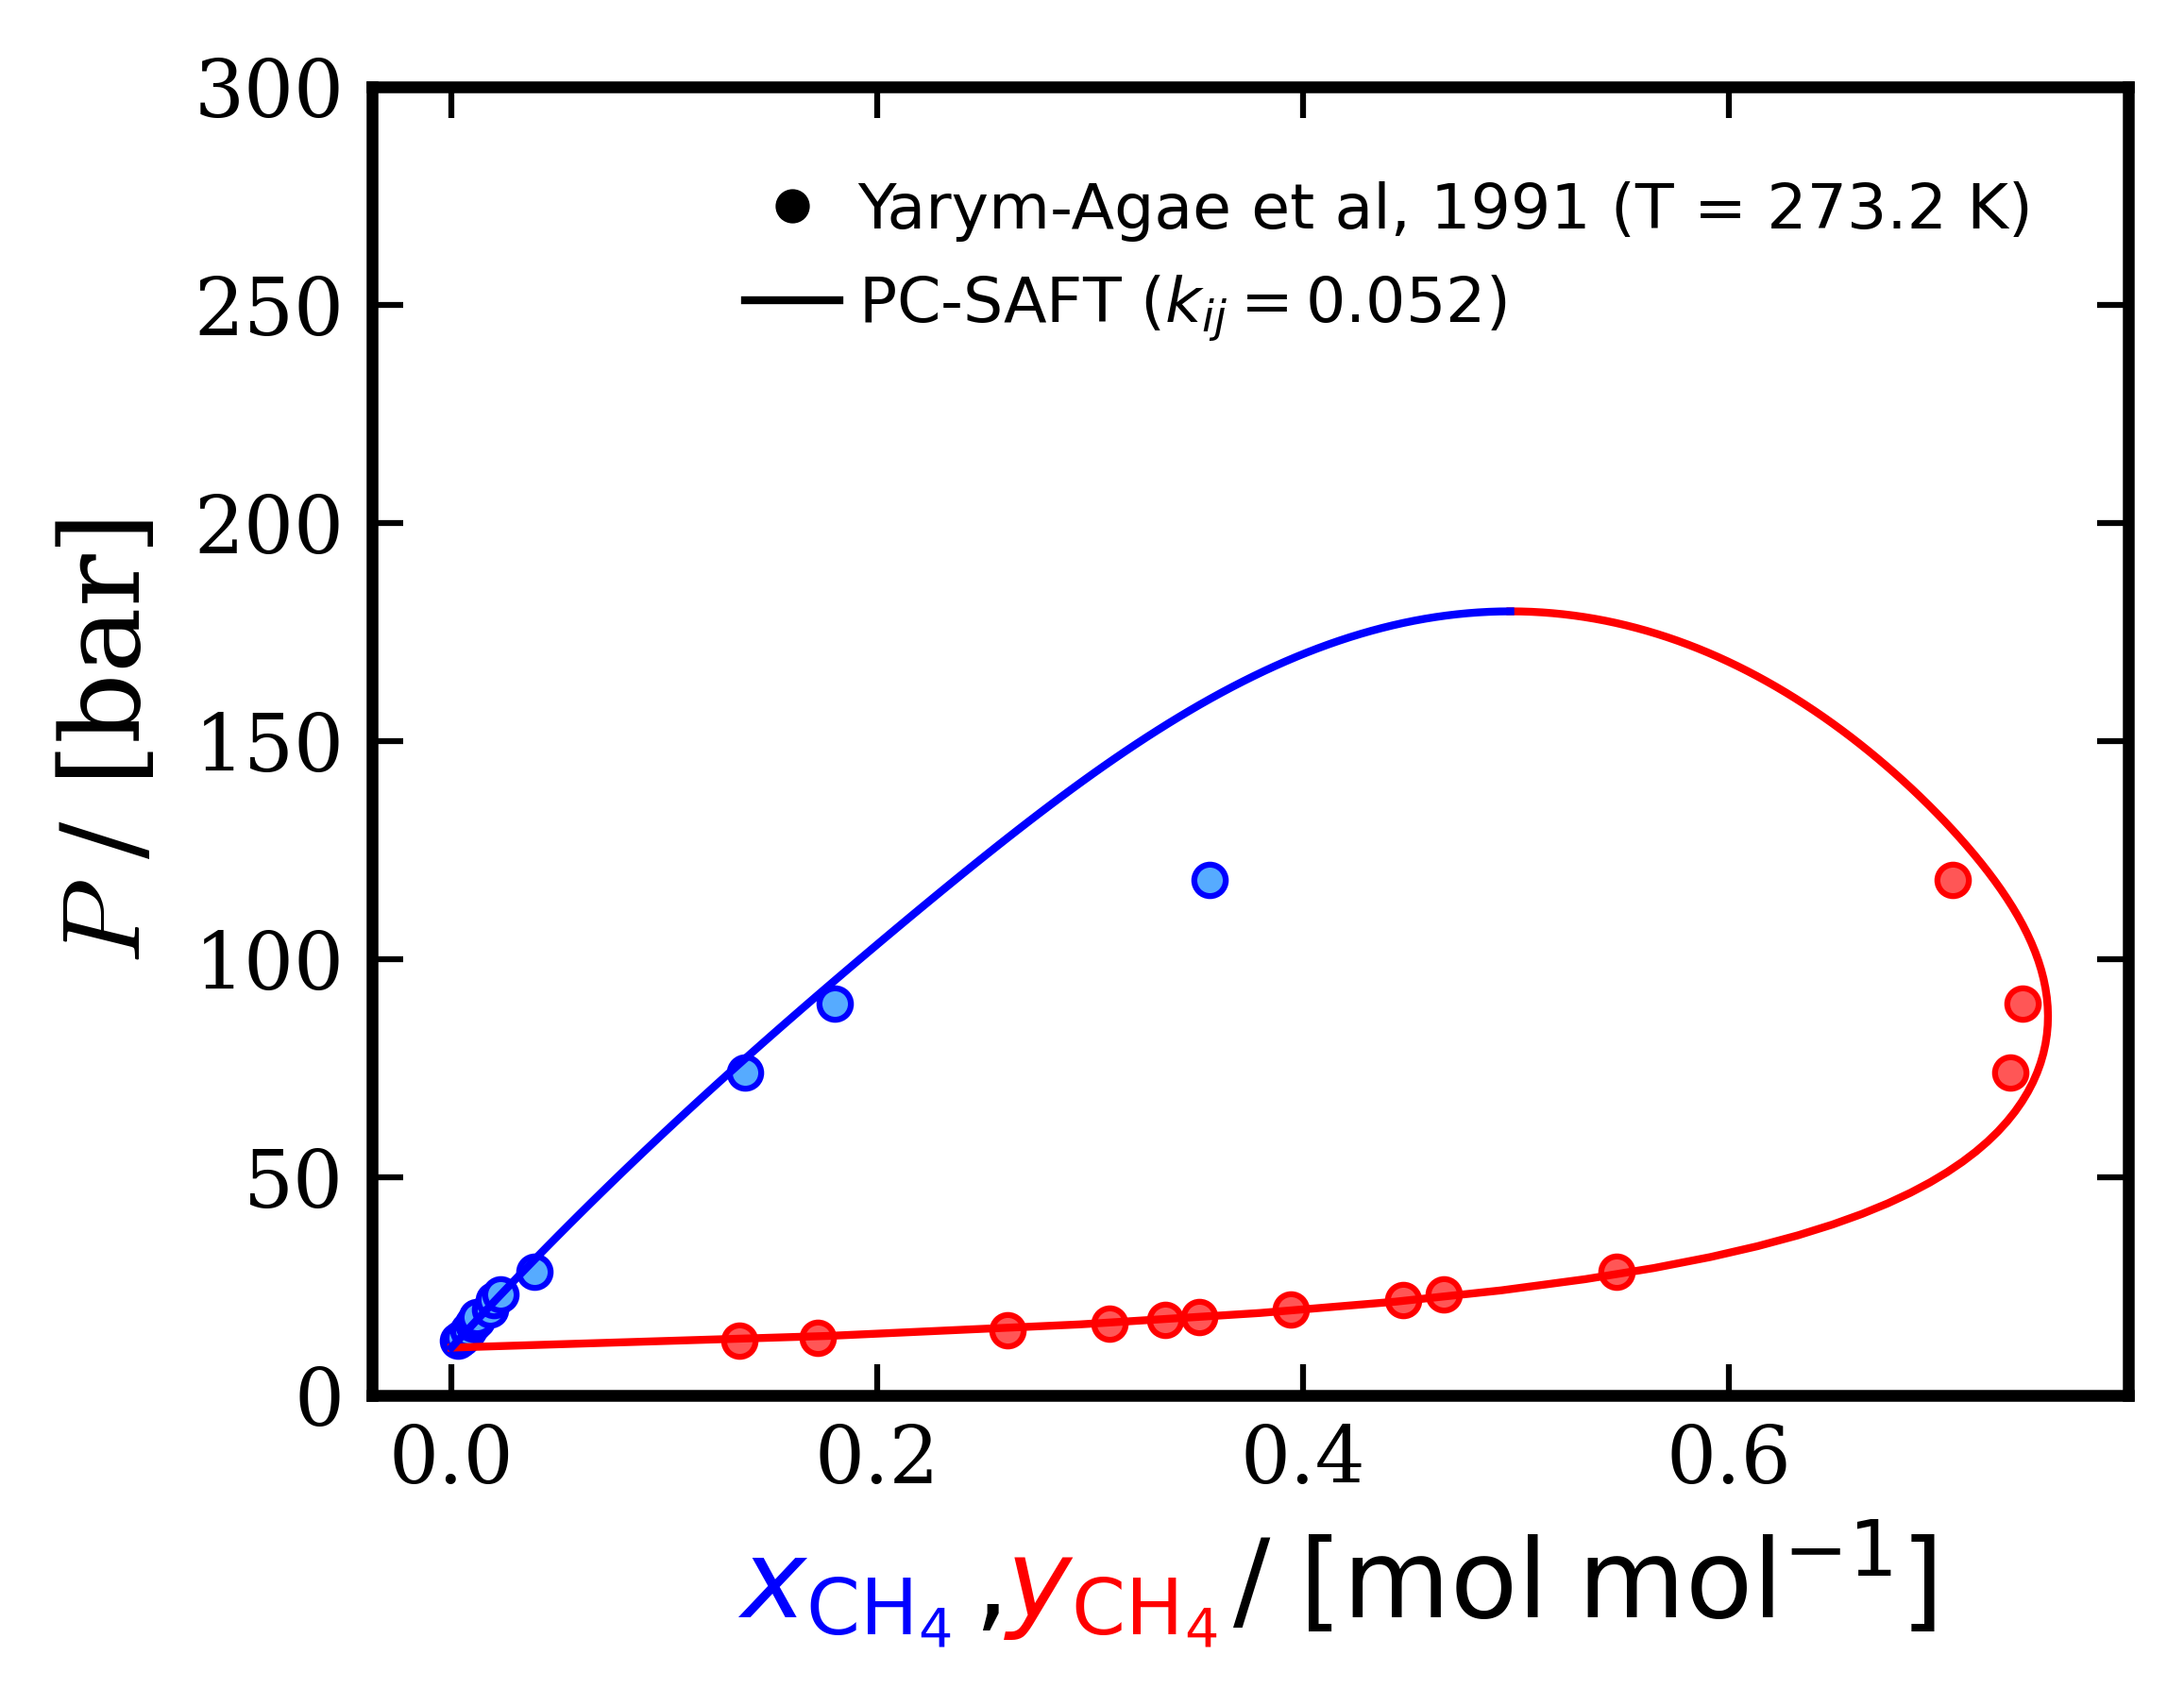

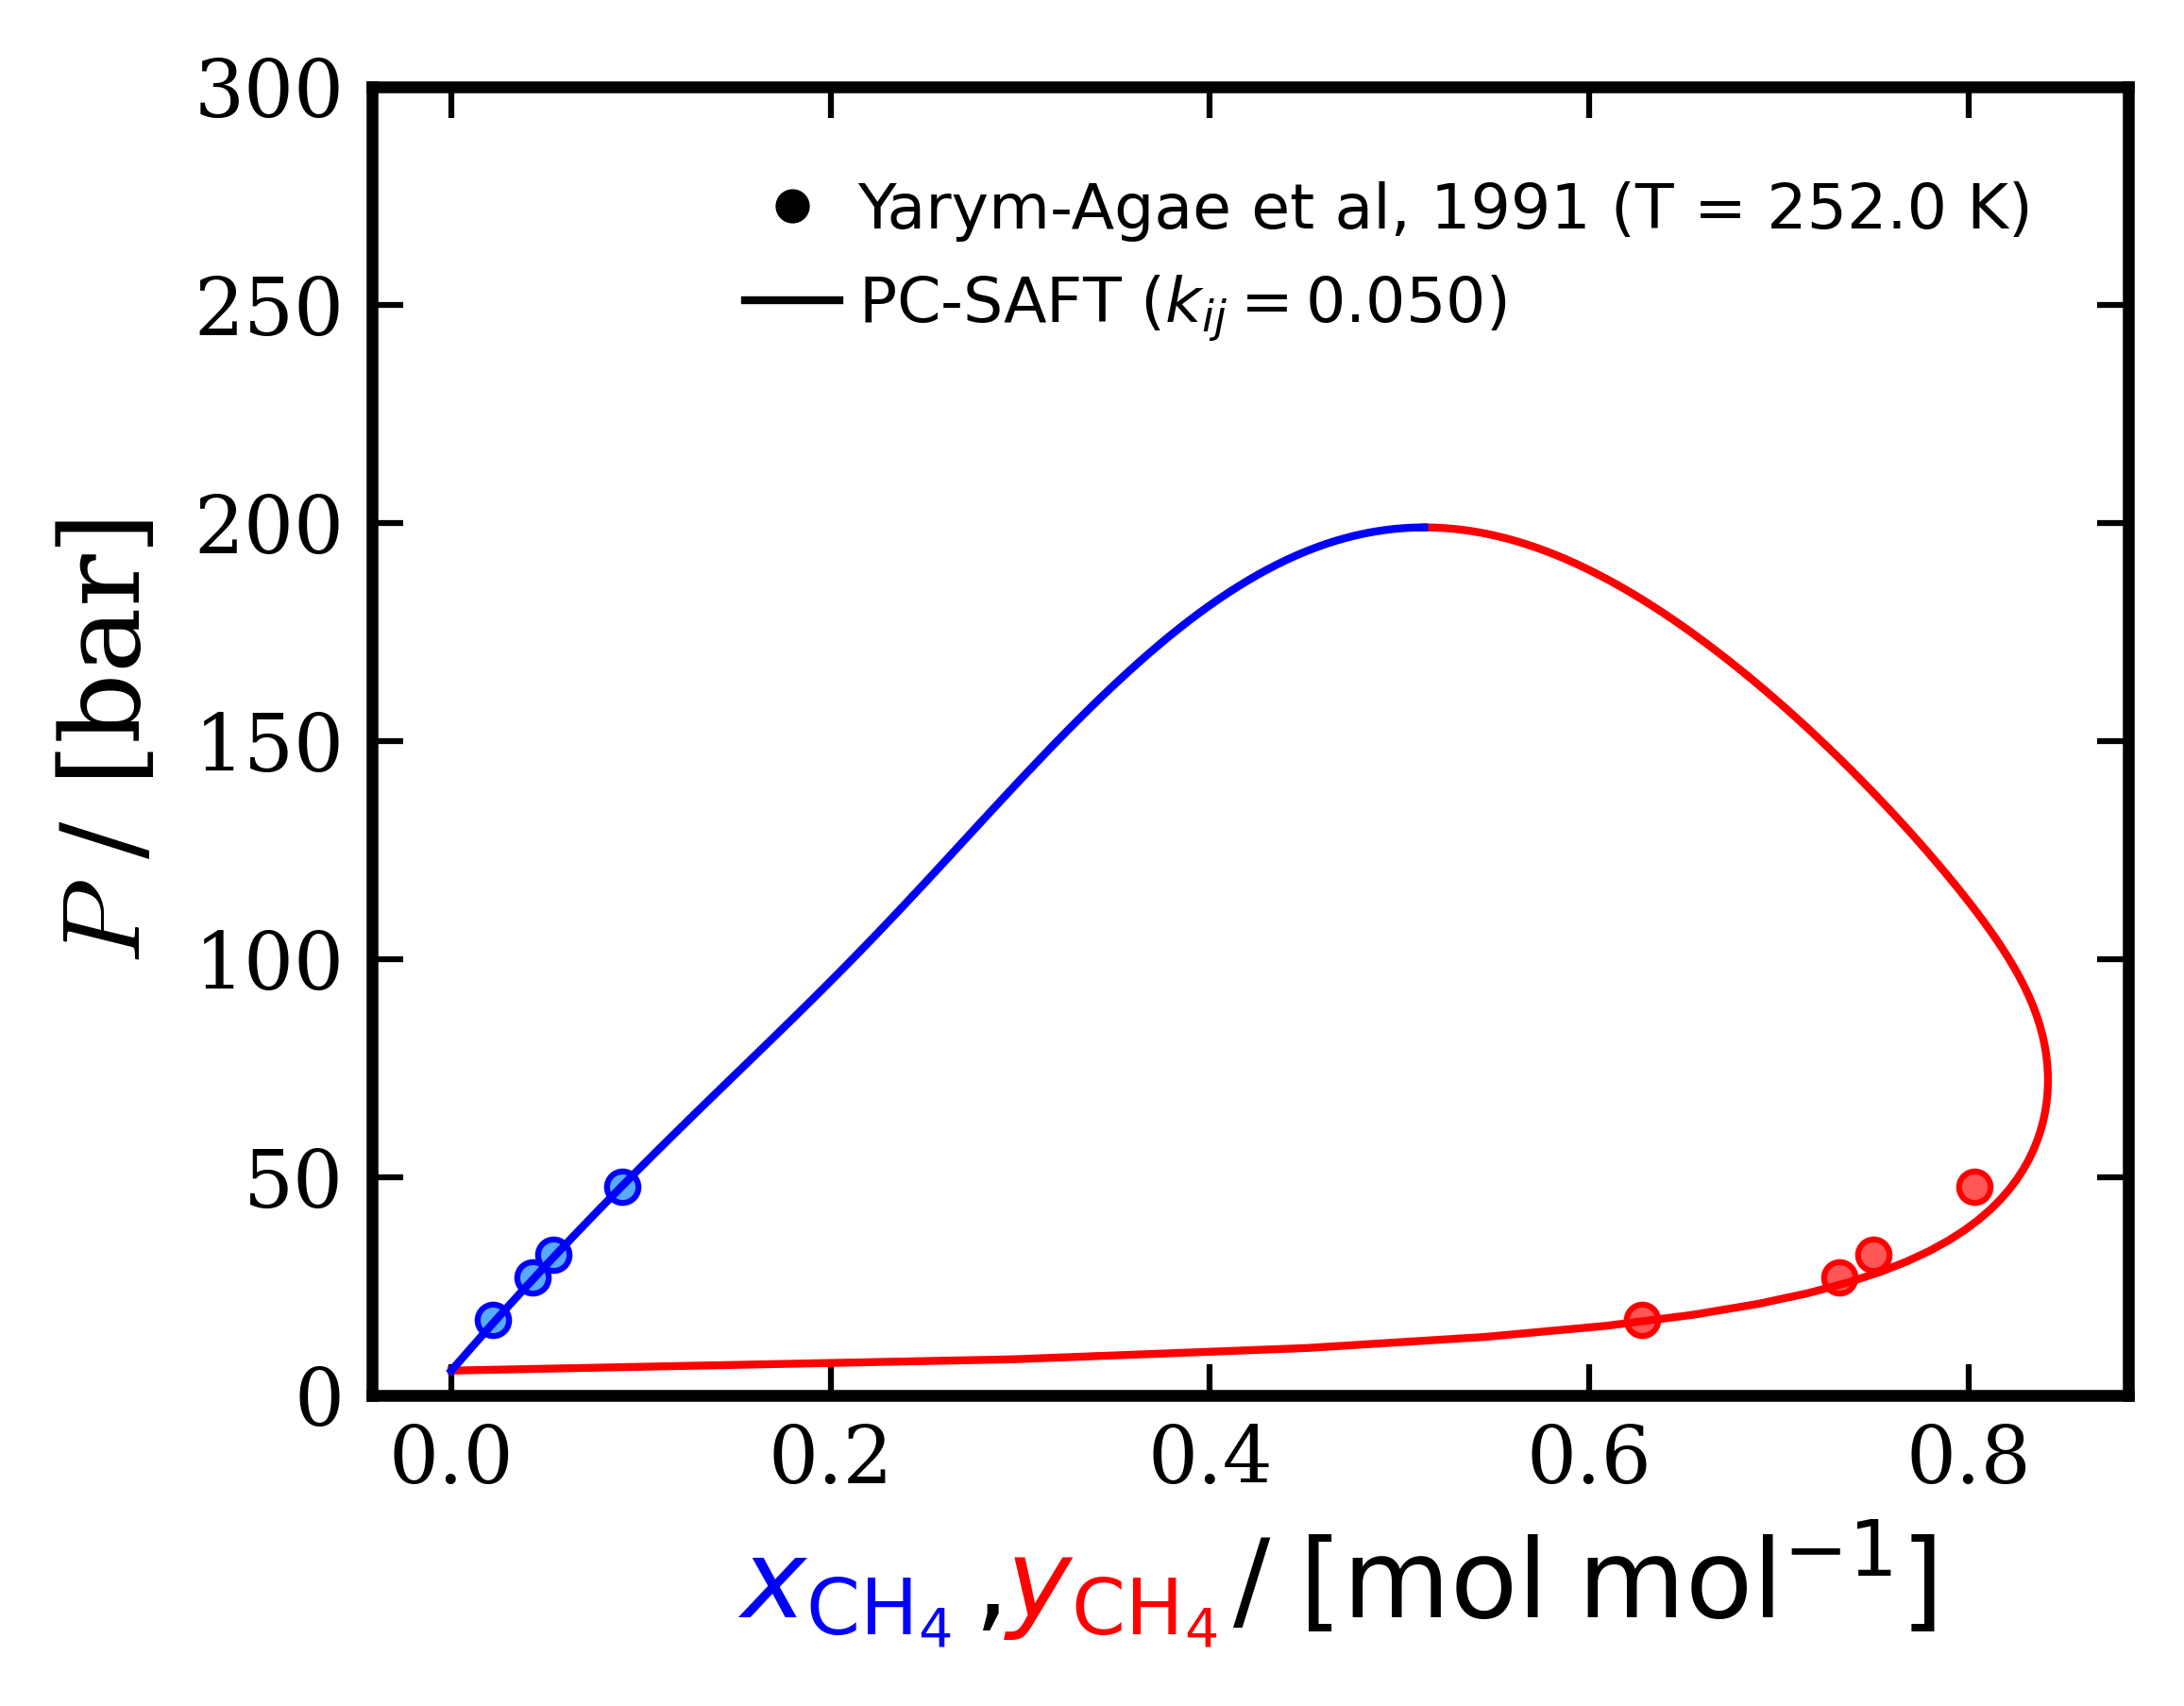

In [11]:
if PLOT == True:
    for T, kij in zip(data[cols["T"]].unique(), kij_mu):
        if np.isnan(kij):
            print(f"Skipping T = {T} K (optimization failed)")
            continue
        VLE_PLOT(mixture, data, cols, T, kij)
        plt.show()


In [12]:
kij_pressure = []

for T in data[cols["T"]].unique():

    isotherm = data[data[cols["T"]] == T]

    if cols['Comp'] in isotherm.columns:
        if isotherm[cols['Comp']].iloc[0] == comp2:
            x = isotherm[cols["x1"]].to_numpy(float)
        else:
            x = 1 - isotherm[cols["x1"]].to_numpy(float)

    ds           = DataSet.binary_vle_pressure(
                       np.full(len(isotherm), T) * KELVIN,
                       isotherm[cols["P"]].values * BAR,
                       x, Phase.Liquid)
    estimator_p  = Estimator([ds], weights=[1], losses=[Loss.linear()])

    try:
        res = optimize_kij_multistart(estimator_p)
        if res is None:
            raise RuntimeError("All starting points failed")

        kij_value  = float(np.atleast_1d(res.x)[0])
        mard_value = float(np.atleast_1d(
                       estimator_p.mean_absolute_relative_difference(
                           eos_from_kij(res.x)) * 100).mean())
        kij_pressure.append(kij_value)

    except Exception as e:
        print(f"kij_pressure failed at T = {T} K: {e}")
        kij_value  = np.nan
        mard_value = np.nan
        kij_pressure.append(np.nan)

    kij_file = os.path.join("PLOTS", "kij_all.csv")
    write_header = not os.path.exists(kij_file)
    with open(kij_file, "a", newline="") as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(["Optimization type", "Temperature_[K]", "kij", "MARD_percentage"])
        writer.writerow(["pressure", T, kij_value, mard_value])

    print(f"T = {T:8.4f} K | kij_p  = {kij_value:+.6f} | MARD = {mard_value:.4f} %")

T = 223.1700 K | kij_p  = +0.050758 | MARD = 5.4147 %
kij_pressure failed at T = 203.4 K: All starting points failed
T = 203.4000 K | kij_p  = +nan | MARD = nan %
T = 273.2000 K | kij_p  = +0.037321 | MARD = 5.1093 %
T = 252.0000 K | kij_p  = +0.052283 | MARD = 1.3955 %


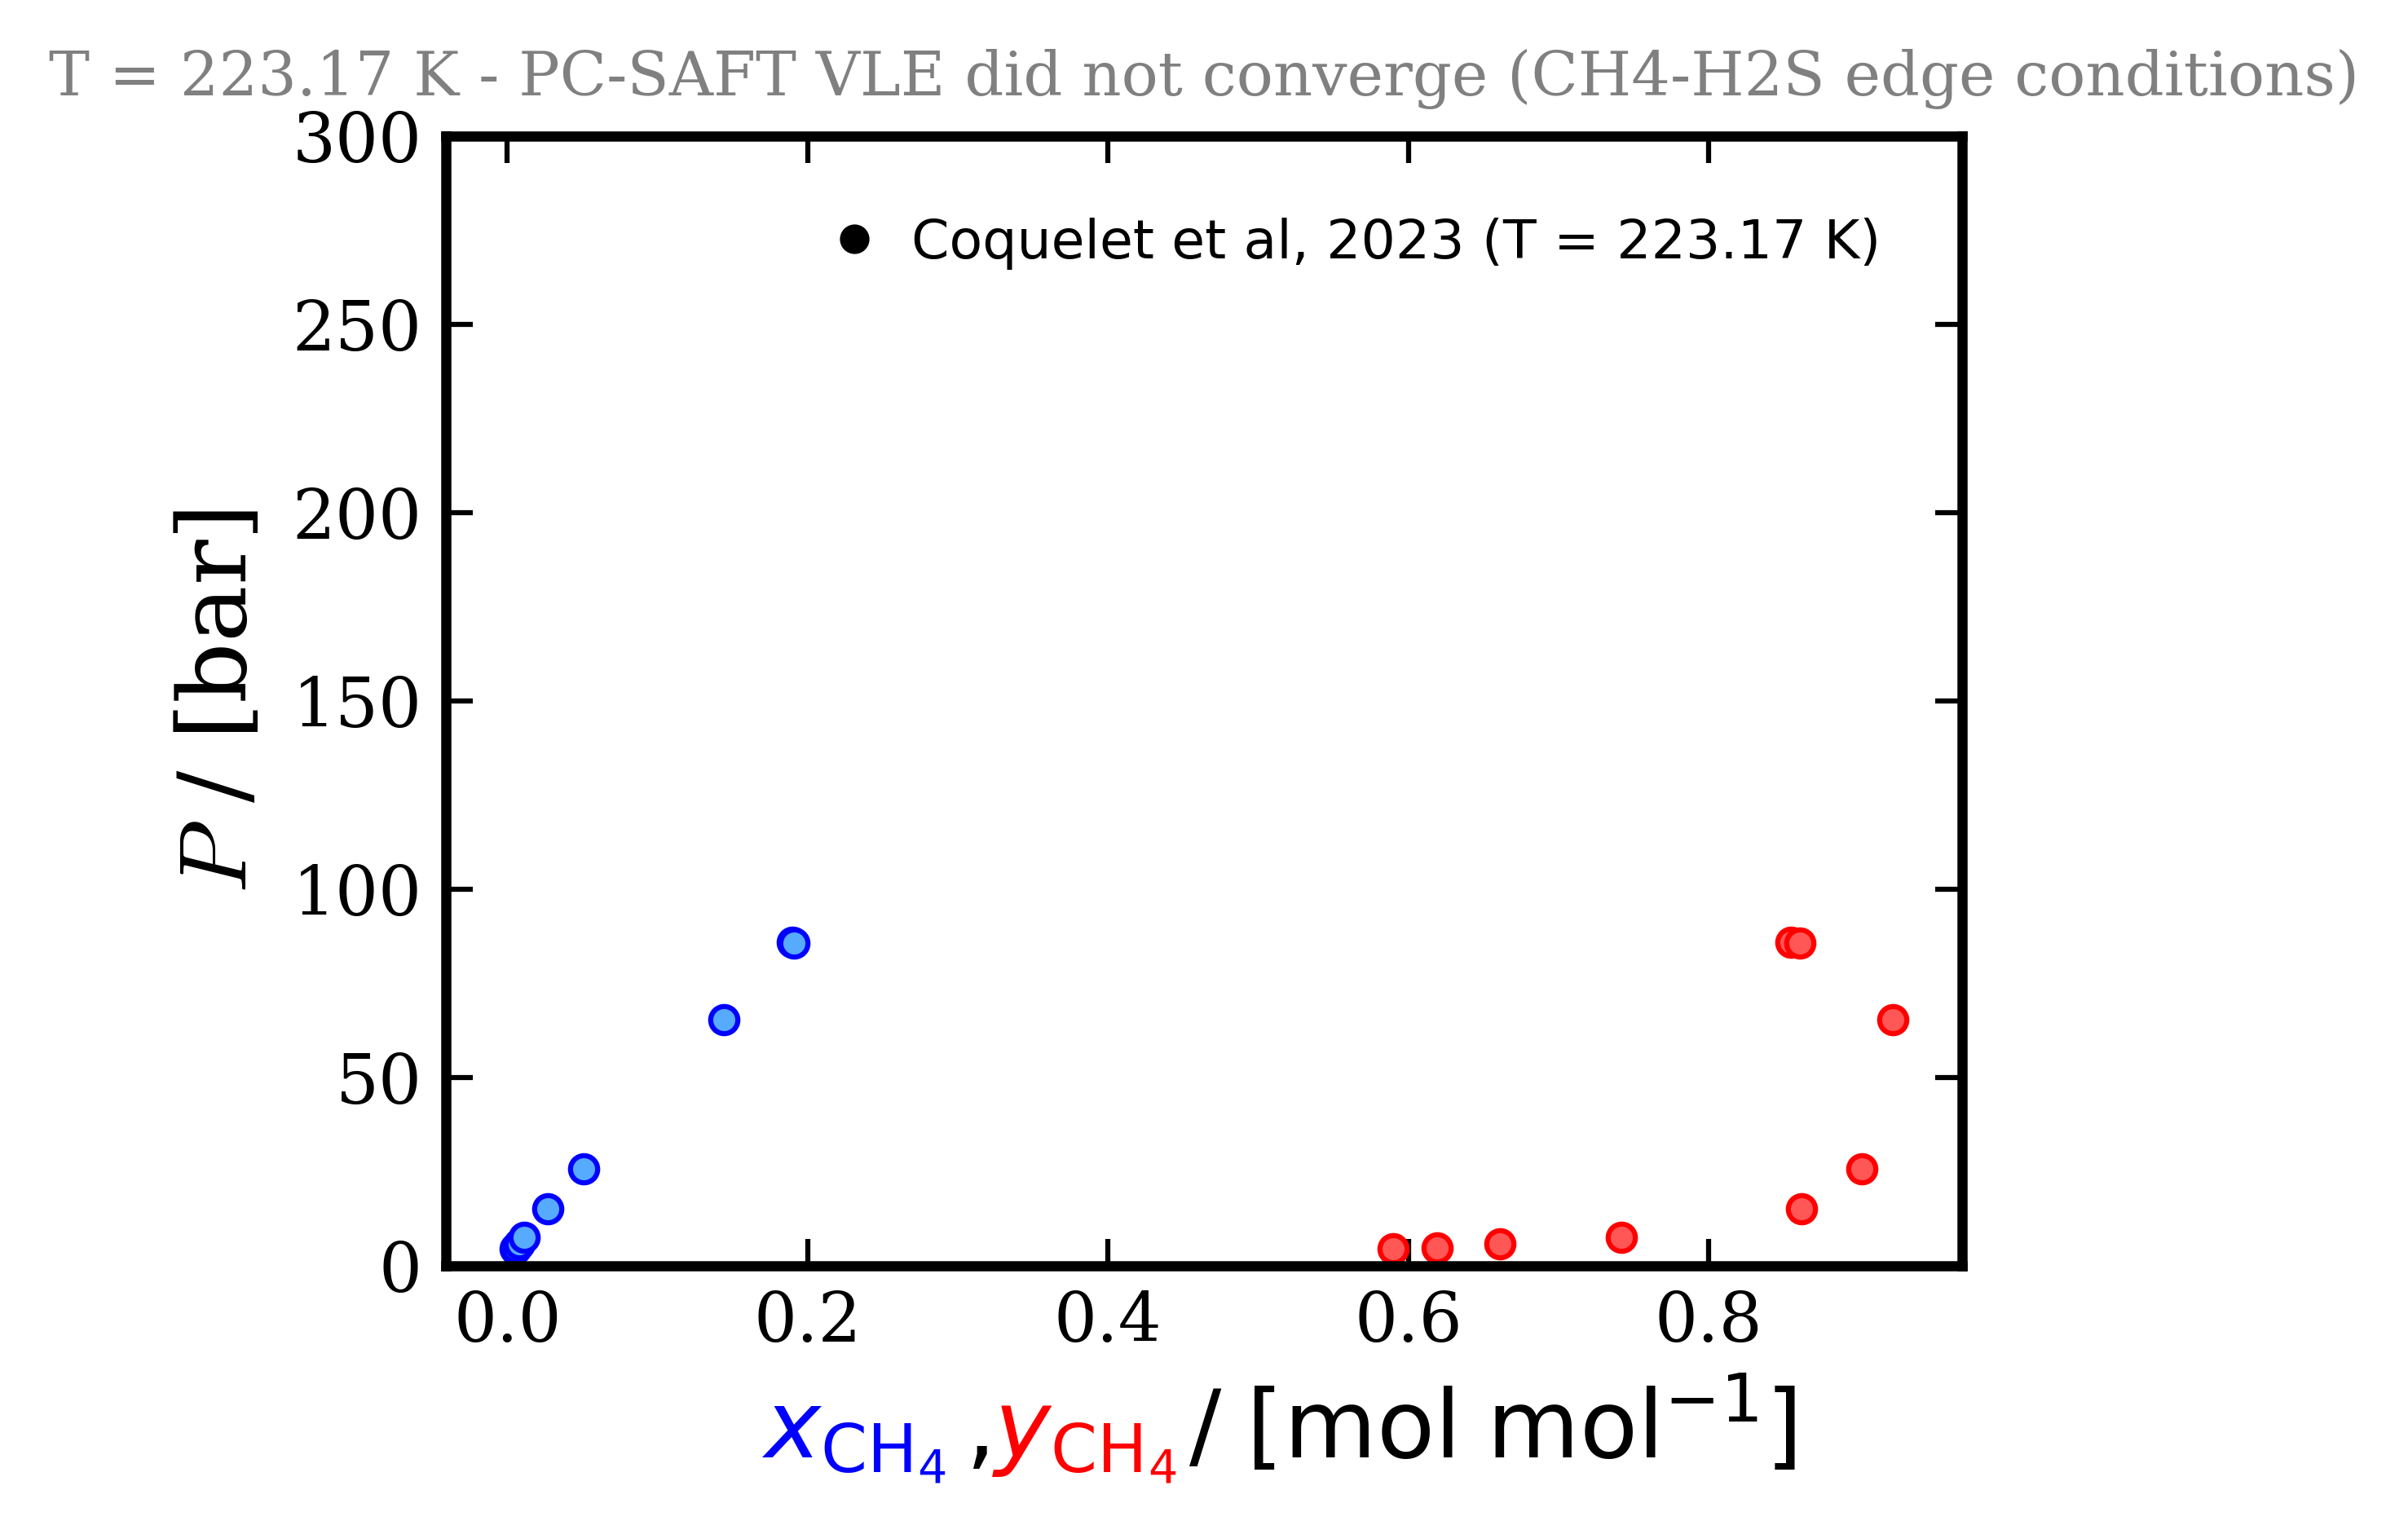

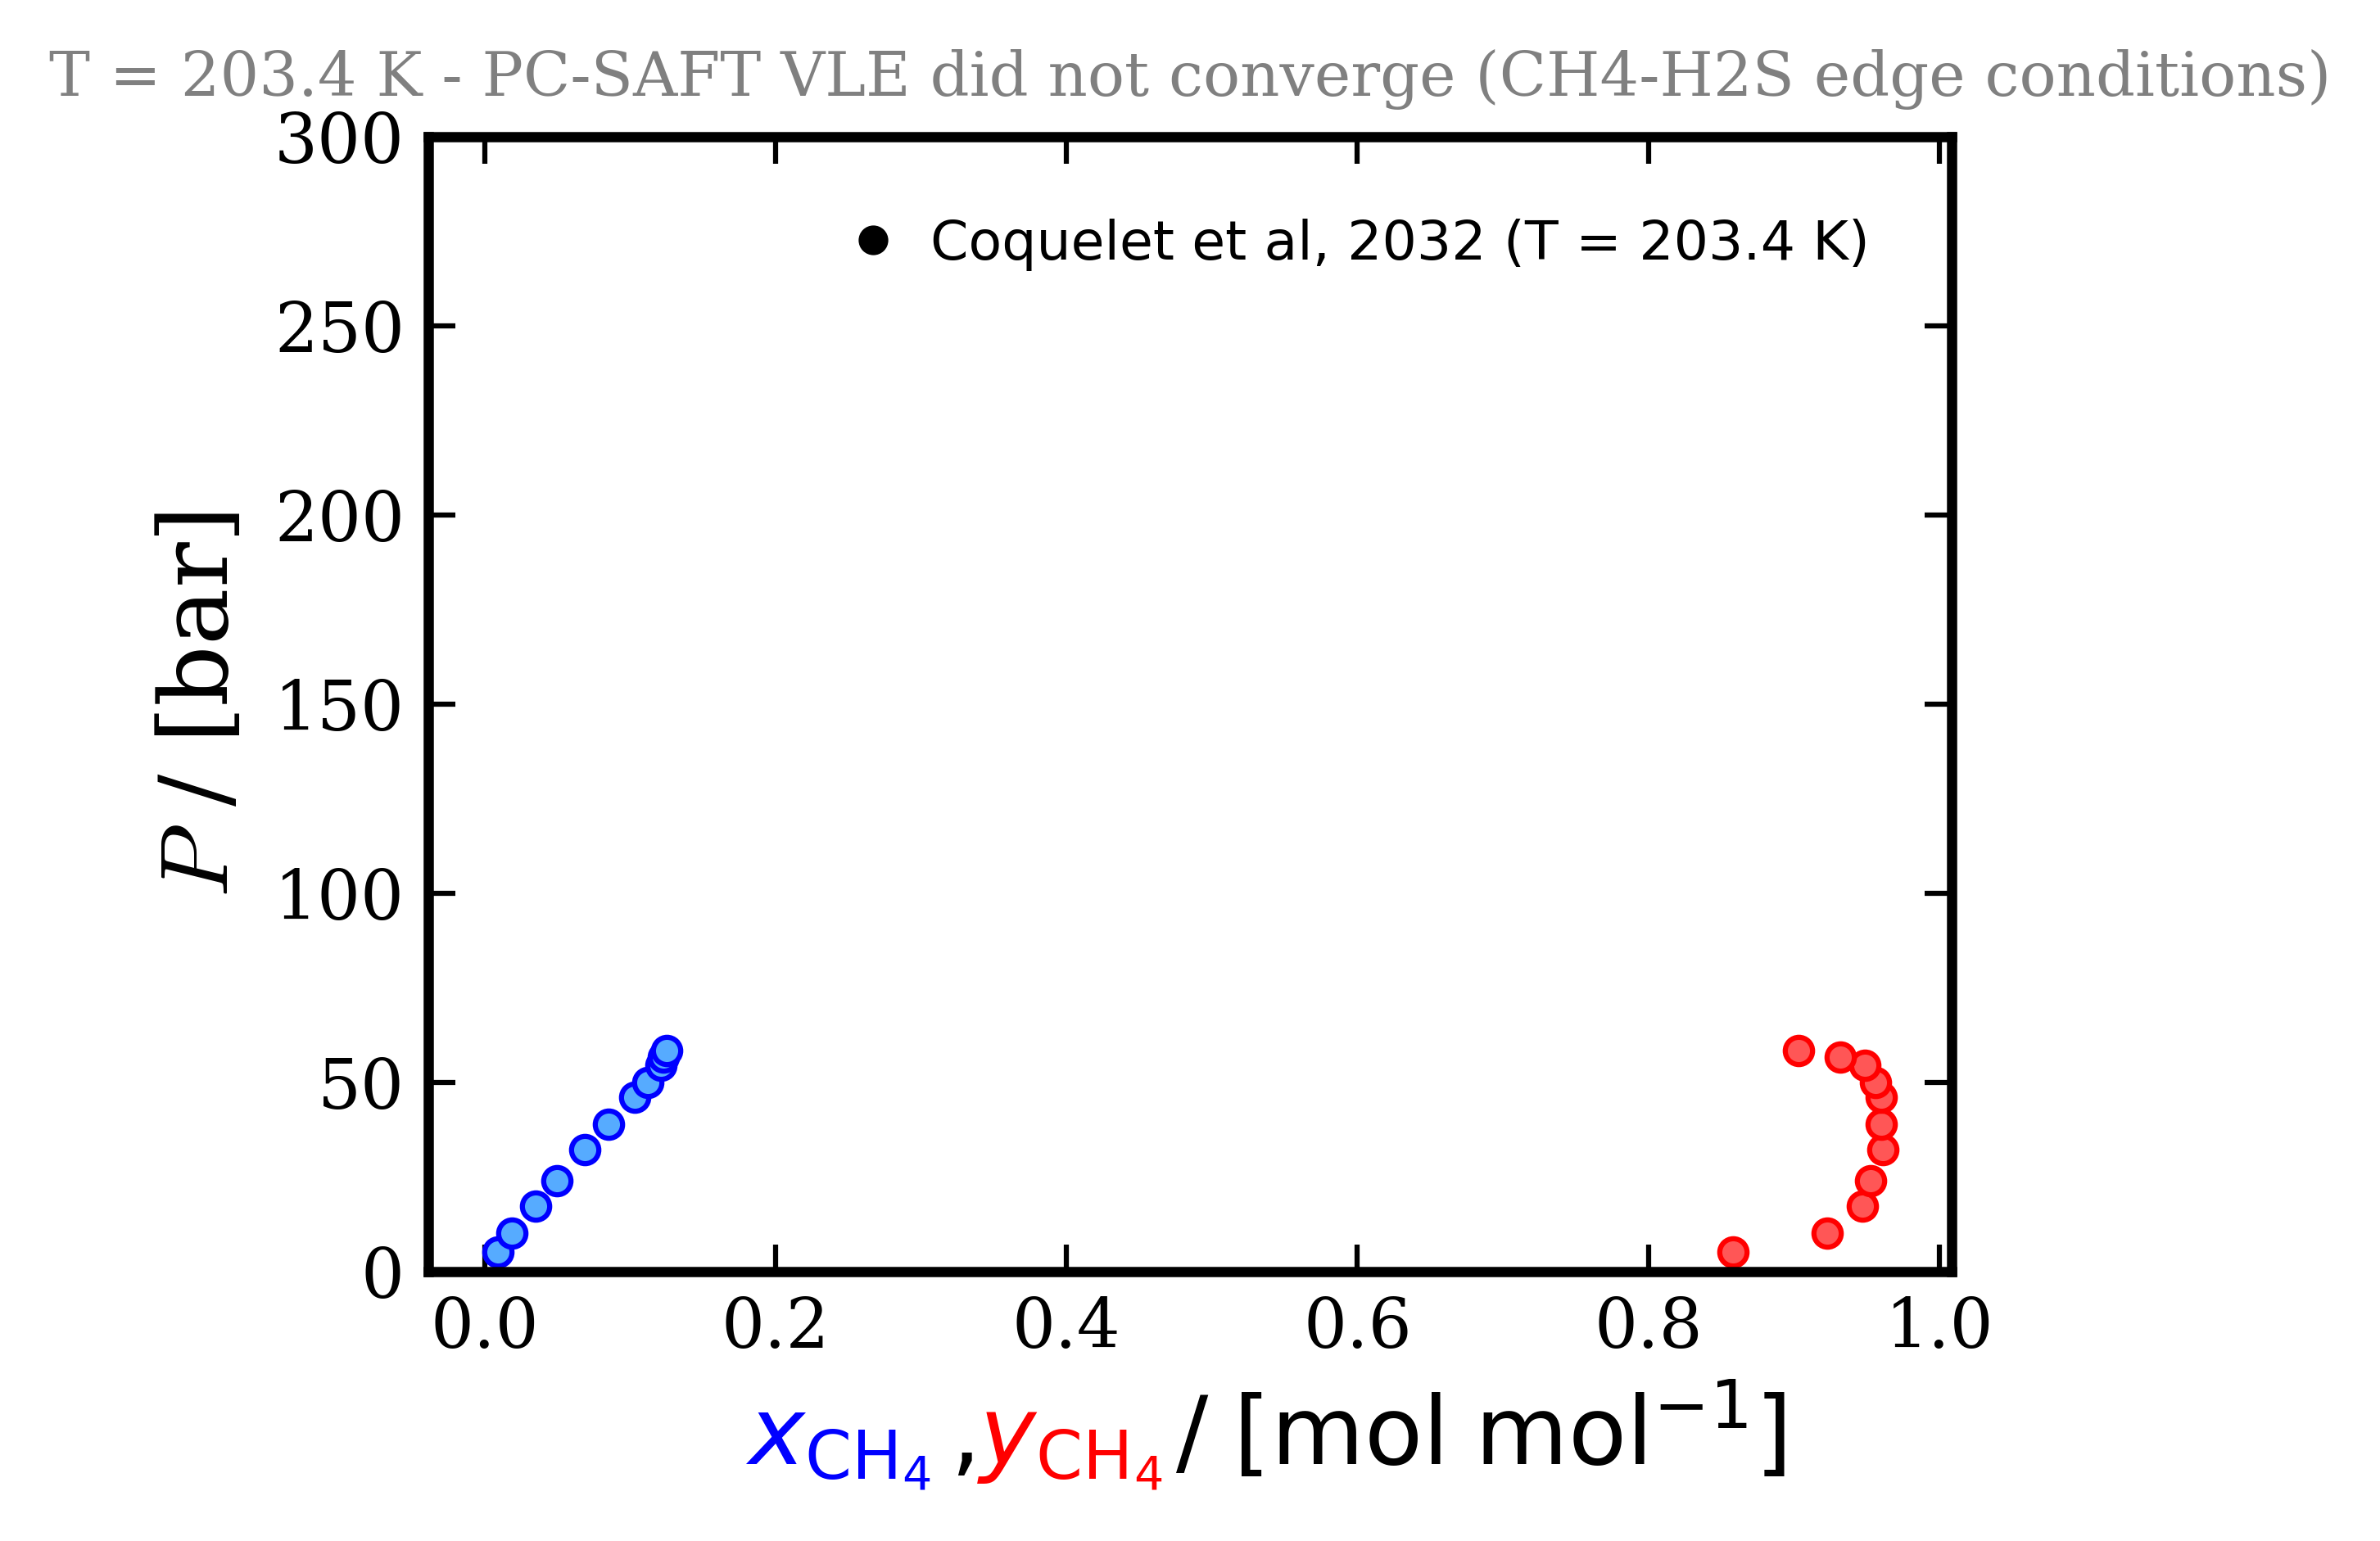

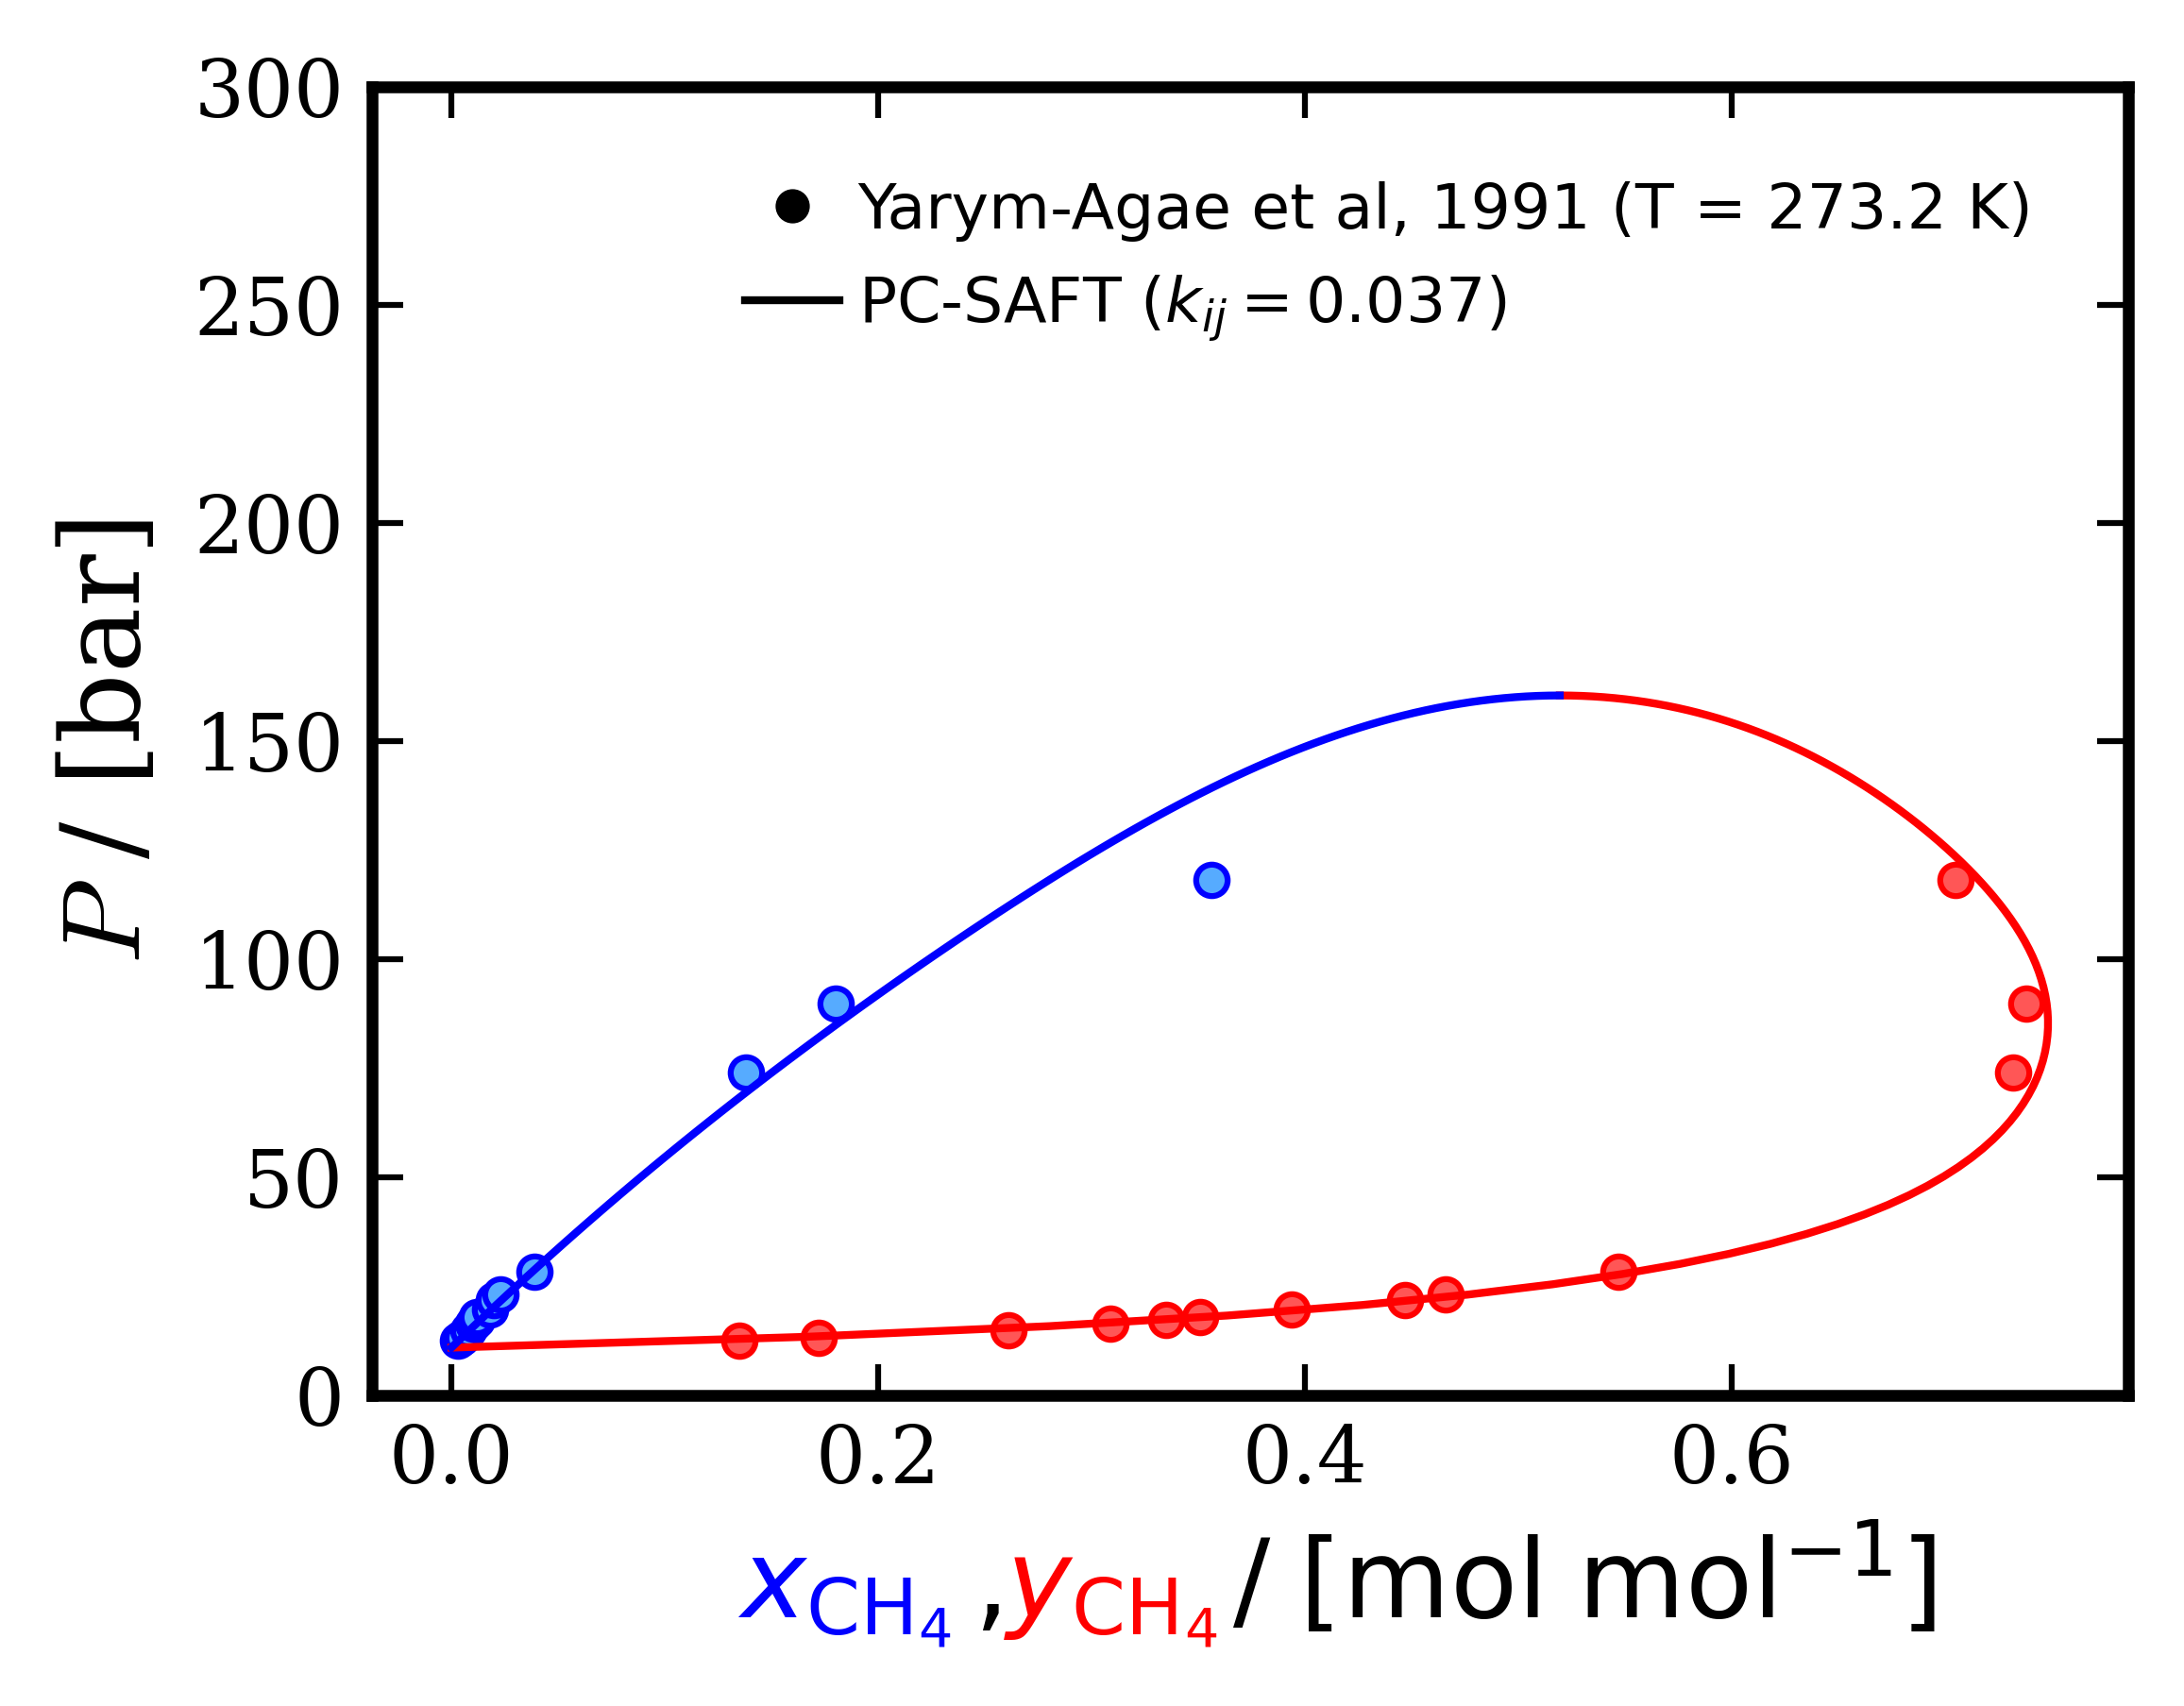

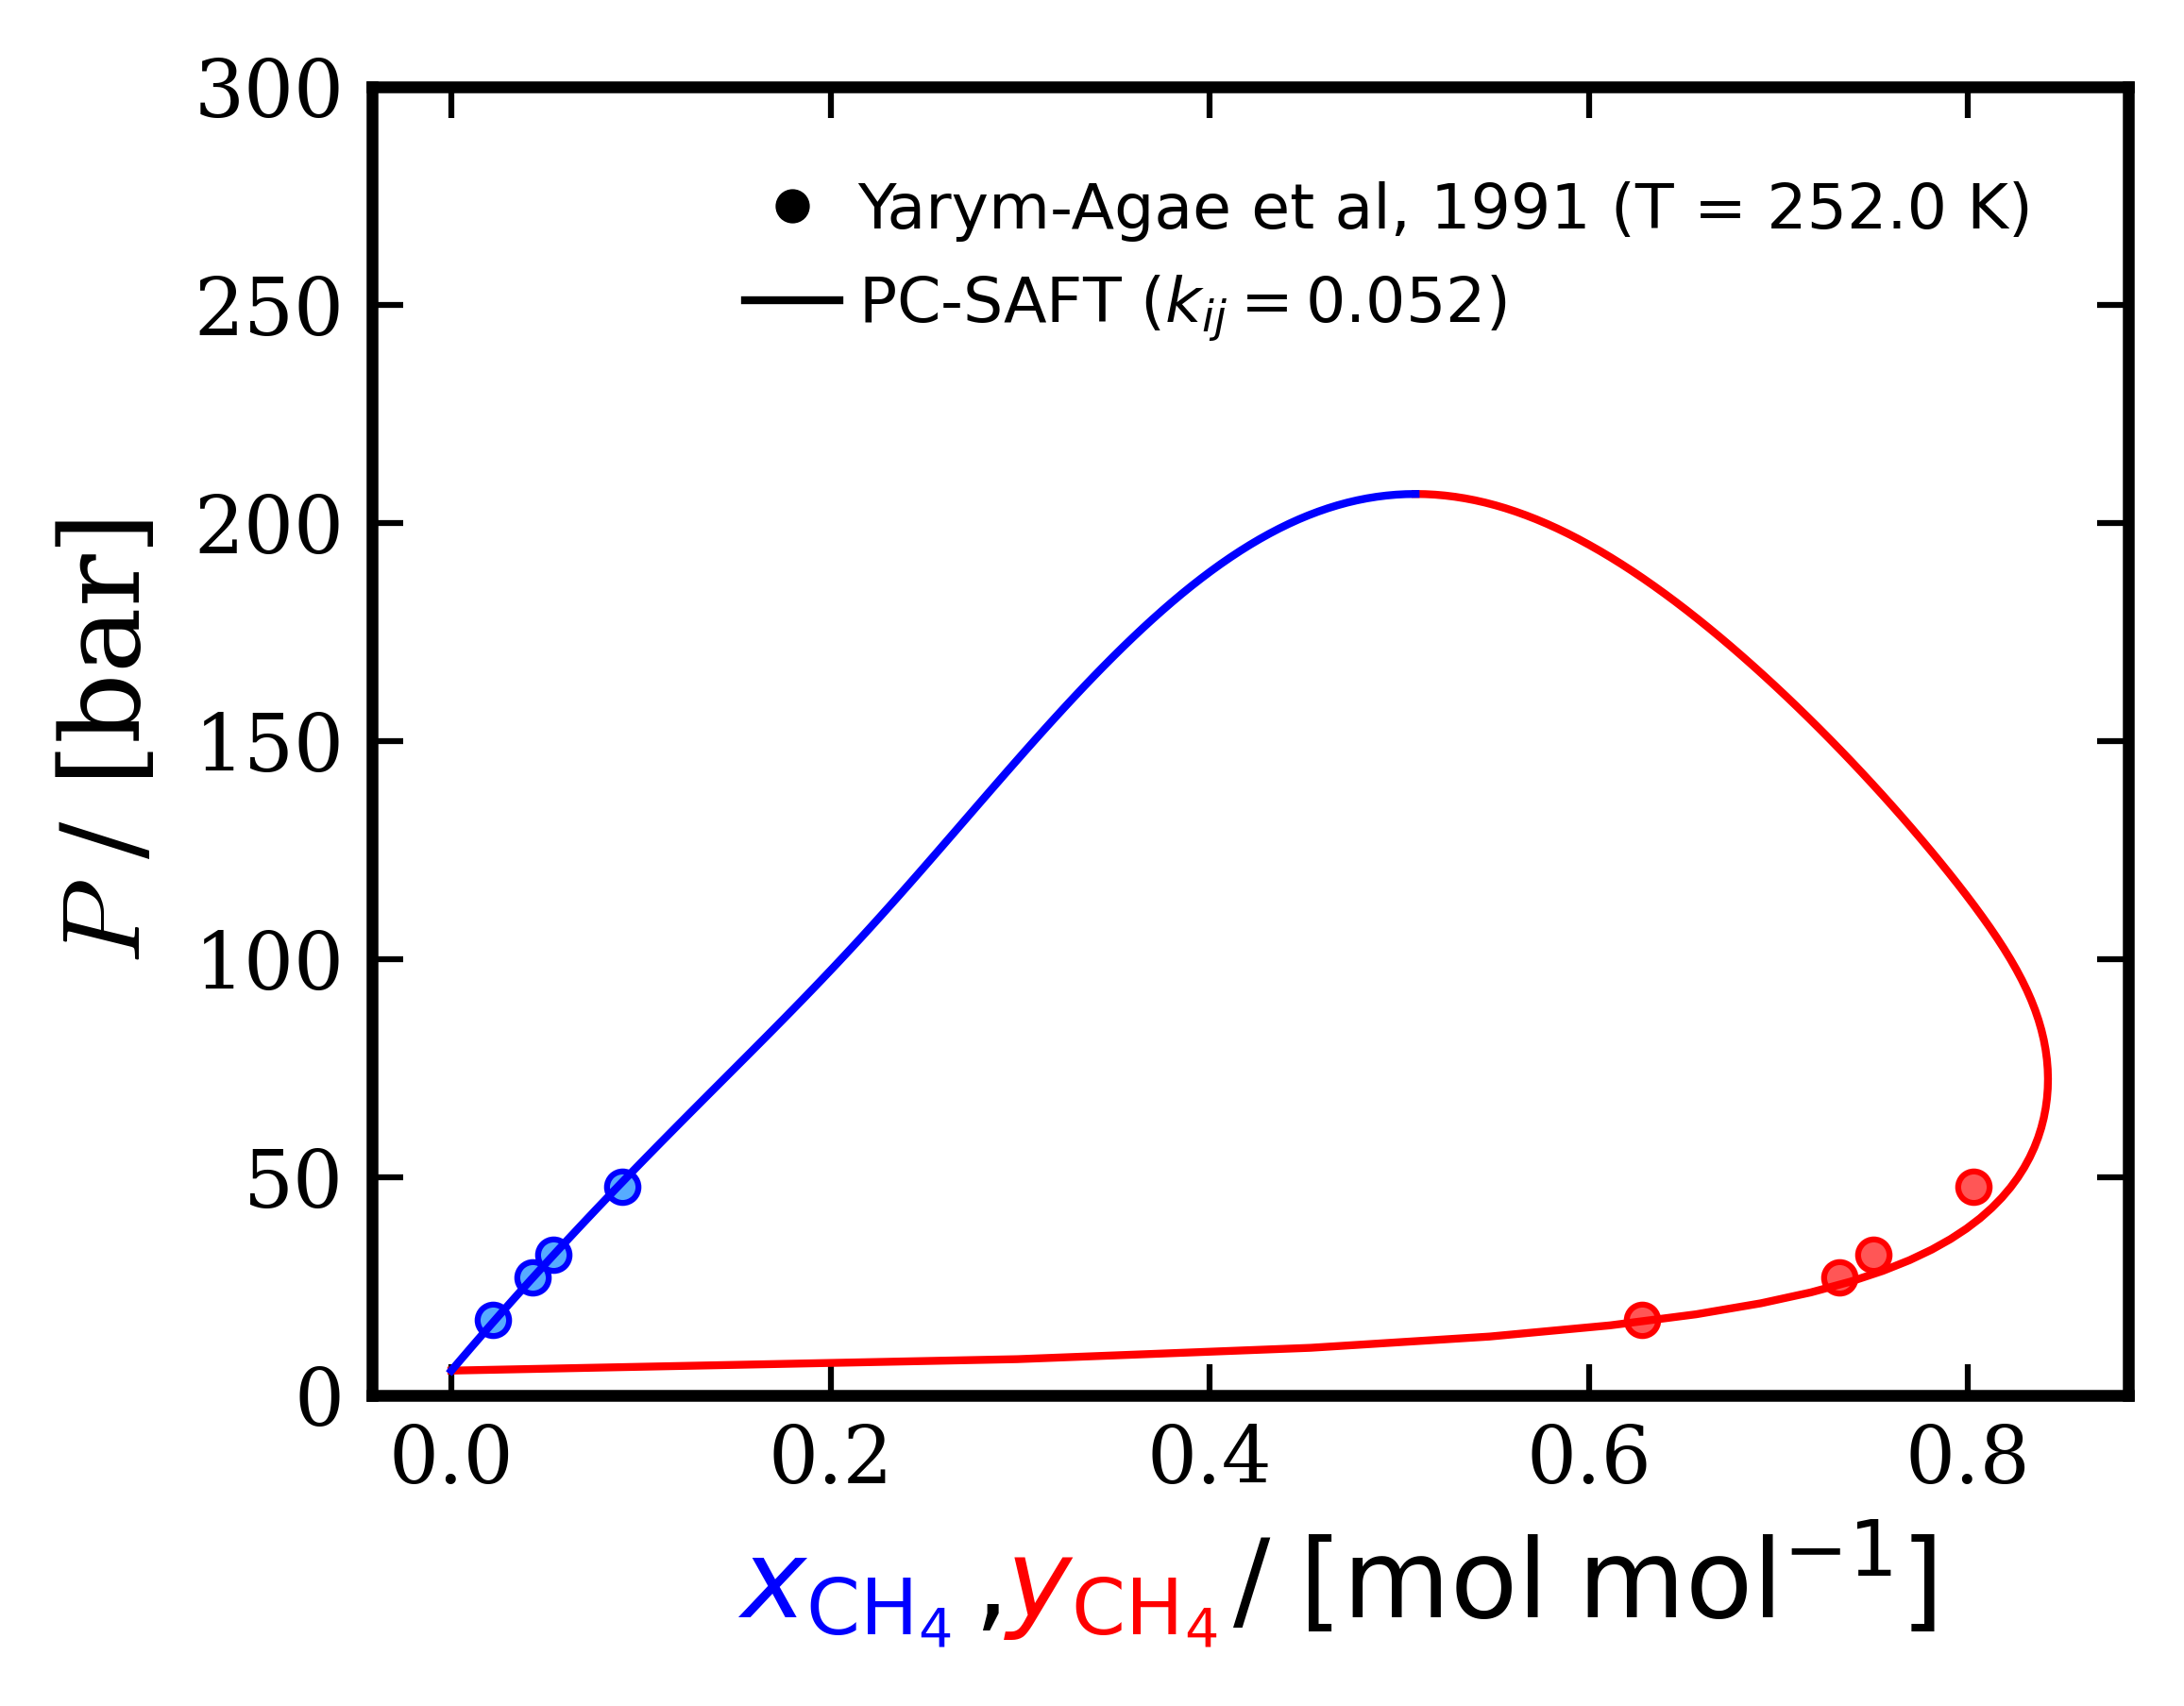

In [13]:
if PLOT == True:
    for T, kij in zip(data[cols["T"]].unique(), kij_pressure):
        try:
            VLE_PLOT(mixture, data, cols, T, kij)
            plt.show()
        except Exception as e:
            print(f"Error plotting VLE for T={T} K and kij={kij}: {e}")
            plt.close()
            continue

In [14]:
## KIJ Interpolation/Extrapolation
df_KIJ      = pd.read_csv("PLOTS/kij_all.csv")

# To take the minimum MARD for each temperature, regardless of optimization type
idx         = df_KIJ.groupby("Temperature_[K]")["MARD_percentage"].idxmin()
df_best_kij = df_KIJ.loc[idx].reset_index(drop=True)
T_min       = df_best_kij["Temperature_[K]"].min()
T_max       = df_best_kij["Temperature_[K]"].max()
kij_mean    = float(df_best_kij["kij"].mean())
kij_std     = float(df_best_kij["kij"].std(ddof=1))

print(df_best_kij)

coeffs_lin,  kij_func_lin,  T_data, kij_data = fit_kij_polynomial(df_best_kij, deg=1)
coeffs_quad, kij_func_quad, T_data, kij_data = fit_kij_polynomial(df_best_kij, deg=2)

    Optimization type  Temperature_[K]       kij  MARD_percentage
0            distance           203.40  0.068232         0.641308
1  chemical potential           223.17  0.056197         2.135427
2            distance           252.00  0.050601         0.465954
3            distance           273.20  0.025852         0.621037

Fitted function:
k_ij(T) = (-5.484648e-04)*T + 1.807237e-01

np.poly1d form:
  
-0.0005485 x + 0.1807

Fitted function:
k_ij(T) = (-6.108619e-06)*T^2 + (2.363176e-03)*T + -1.618744e-01

np.poly1d form:
             2
-6.109e-06 x + 0.002363 x - 0.1619


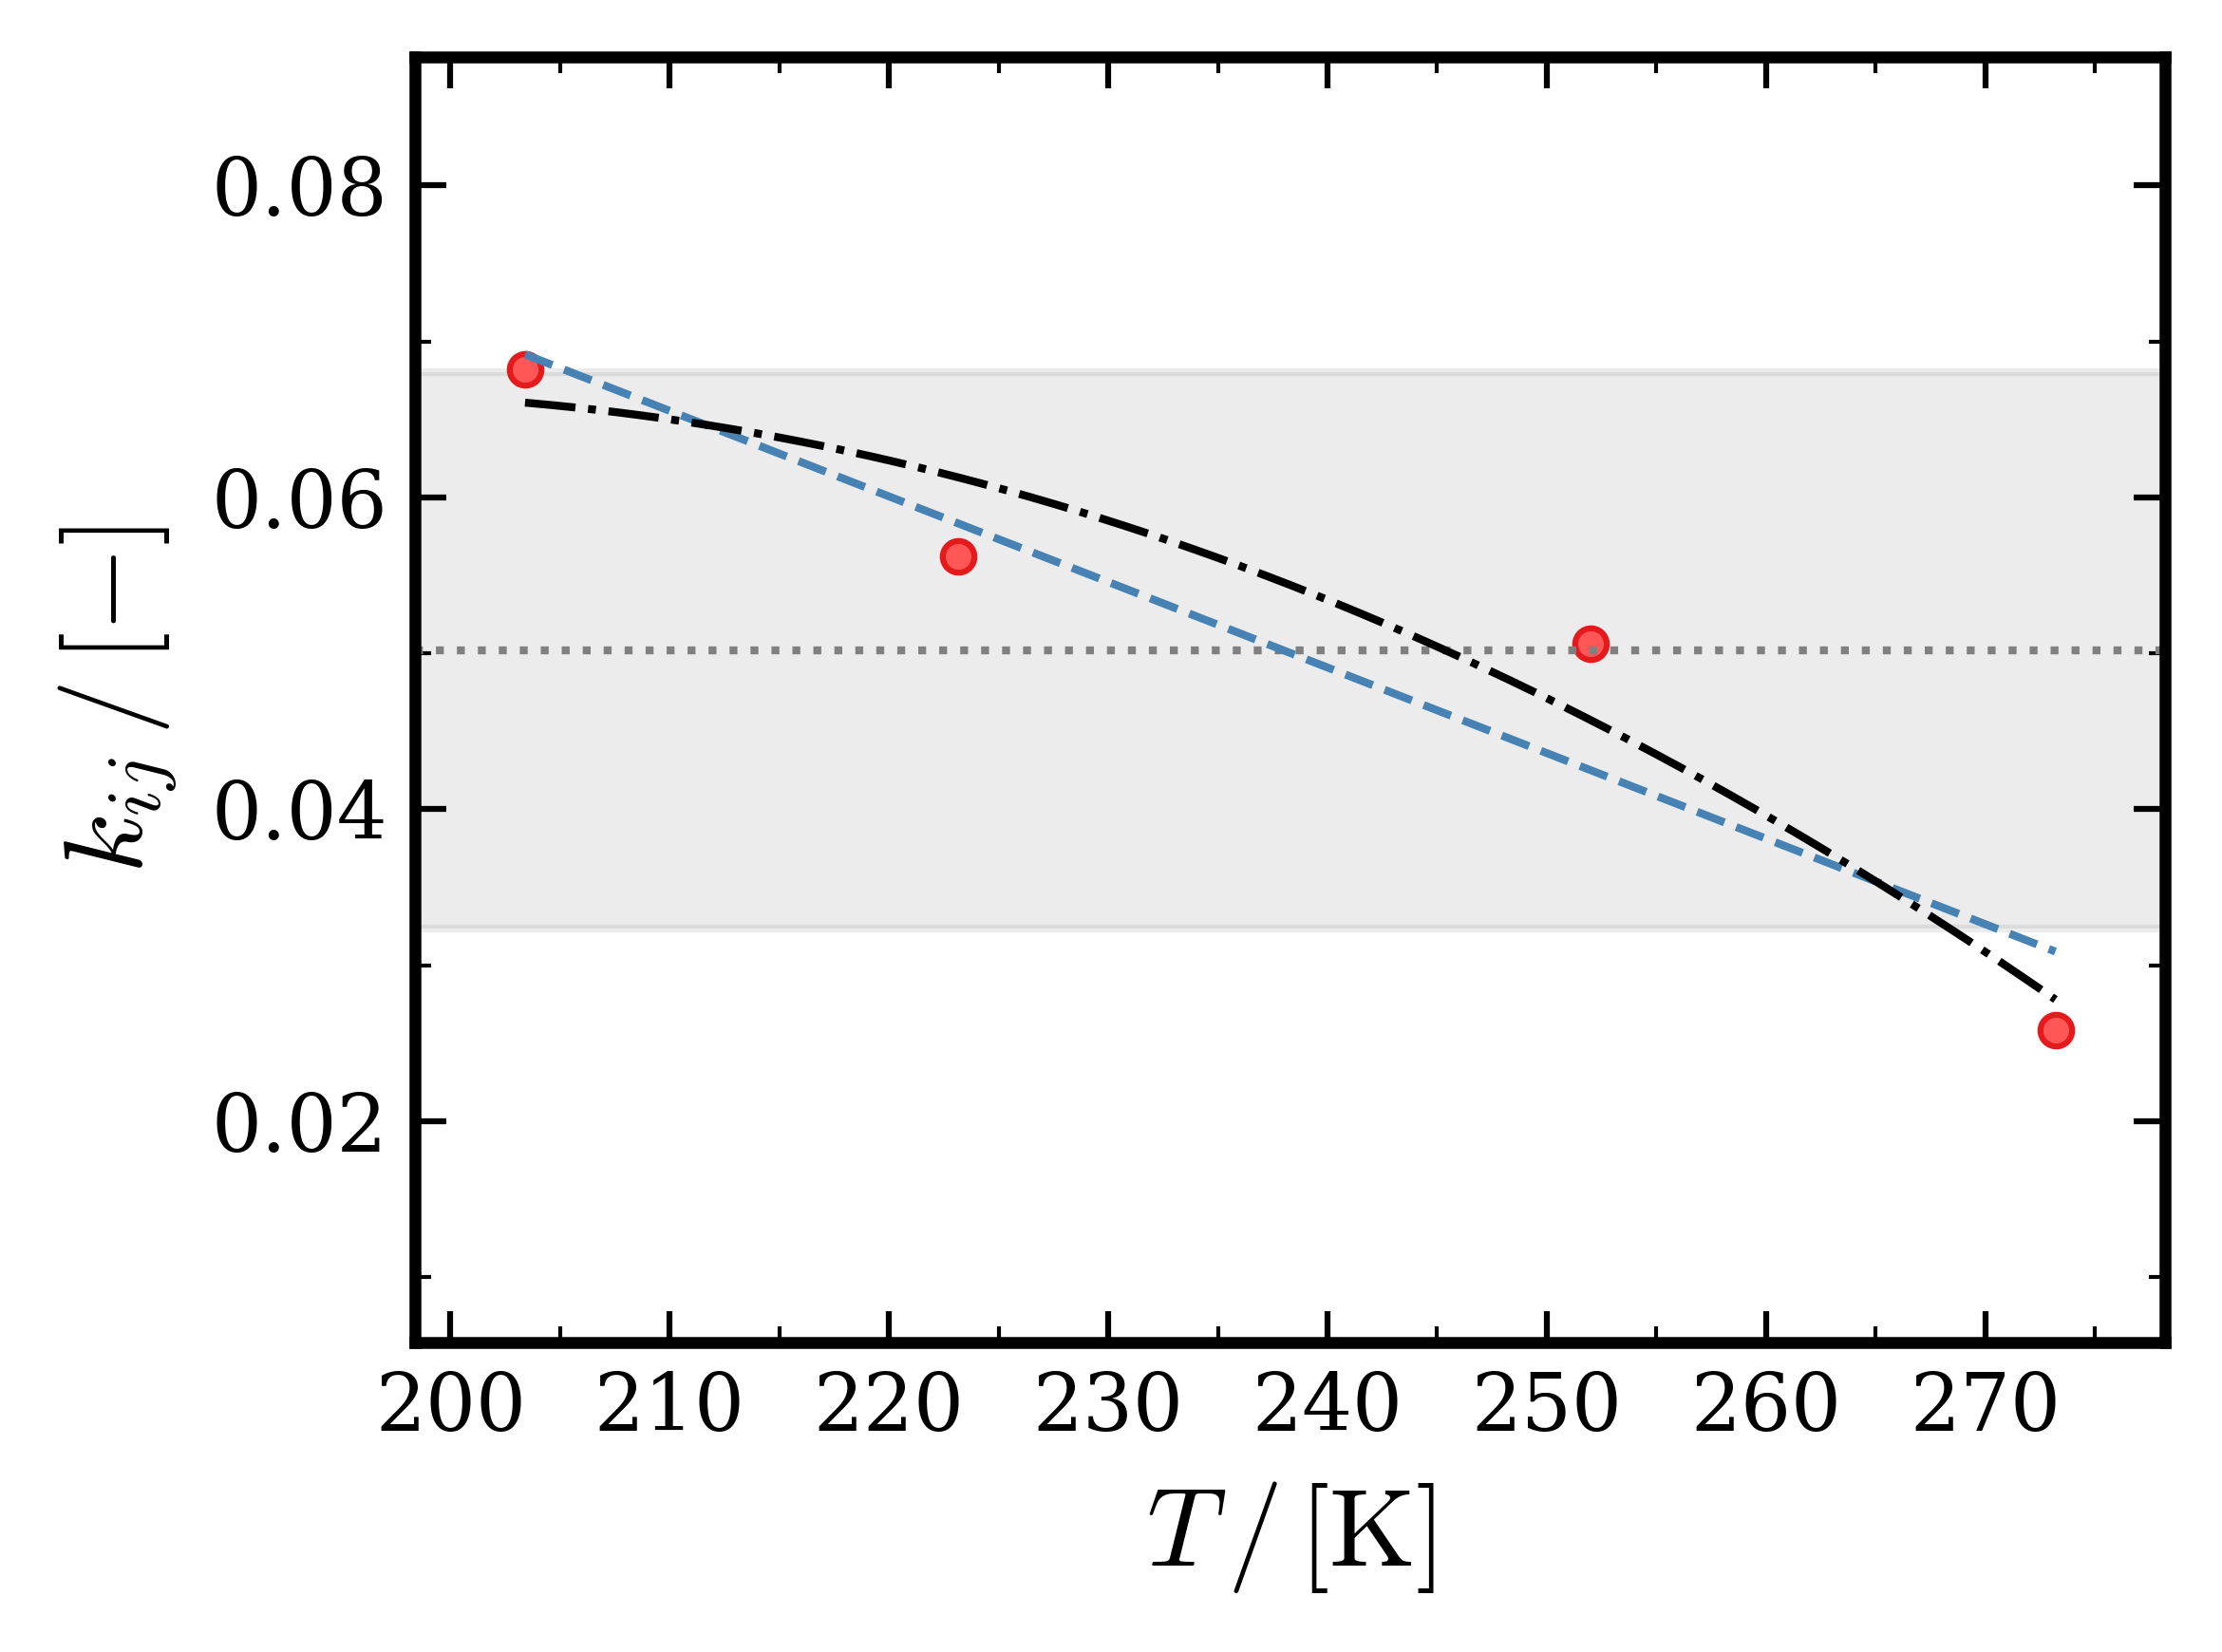

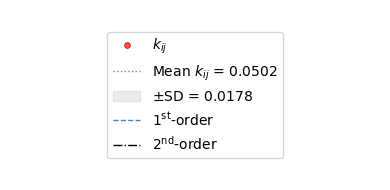

In [15]:
T_fit           = np.linspace(T_data.min(), T_data.max(), nfit)
kij_fit_lin     = kij_func_lin(T_fit)
kij_fit_quad    = kij_func_quad(T_fit)

fig1, ax1 = ps.plot_init()

ax1.plot(df_best_kij["Temperature_[K]"], df_best_kij["kij"],linestyle="",
    linewidth=ps.linewidth,marker=ps.markers[0],markersize=ps.markersize, markerfacecolor="#FF5656",
    markeredgewidth=ps.markeredgewidth,color=ps.colors[0],
    label=r"$k_{ij}$")

# Constant: mean and SD as horizontal band
ax1.axhline(kij_mean, color="gray", linewidth=ps.linewidth, linestyle=":",
    label=rf"Mean $k_{{ij}}$ = {kij_mean:.4f}")
ax1.axhspan(kij_mean - kij_std, kij_mean + kij_std,
    alpha=0.15, color="gray",
    label=rf"$\pm$SD = {kij_std:.4f}")

# Linear fit
ax1.plot(T_fit, kij_fit_lin, color="steelblue", linewidth=ps.linewidth, linestyle="--",
    label=r"1$^{\mathrm{st}}$-order")

# Quadratic fit
ax1.plot(T_fit, kij_fit_quad, color="k", linewidth=ps.linewidth, linestyle="-.",
    label=r"2$^{\mathrm{nd}}$-order")
    
ax1.set_xlabel(r"$T\,/\, \mathrm{[K]}$", fontsize=ps.label_fontsize)
ax1.set_ylabel(r"$k_{ij}\, / \, [-]$", fontsize=ps.label_fontsize)
# ps.style_legend(ax1, loc='lower left', ncol=1, borderaxespad=1.0, frame=True)

ax1.minorticks_on()
ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.02))
ax1.yaxis.set_minor_locator(ticker.MultipleLocator(0.01))
ax1.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax1.xaxis.set_minor_locator(ticker.MultipleLocator(5))

ax1.set_xlim(T_data.min() - 5, T_data.max() + 5)
ax1.set_ylim(kij_data.min() - 0.02, kij_data.max() + 0.02)

fig1.tight_layout()
ps.save_plot(fig1, f"kij_{mixture.replace('-','-')}_vs_T")
plt.show()

# Separate legend figure
handles, labels = ax1.get_legend_handles_labels()
fig_leg, ax_leg = plt.subplots(figsize=(4, 2))
ax_leg.axis("off")
ax_leg.legend(handles, labels, loc="center", ncol=1, frameon=True)
fig_leg.tight_layout()
ps.save_plot(fig_leg, f"kij_{mixture.replace('-', '-')}_legend")
plt.show()

In [16]:
out = {
    "T_min": T_min,
    "T_max": T_max,
    "constant": {
        "deg"   : 0,
        "mean"  : kij_mean,
        "std"   : kij_std
    },
    "linear": {
        "deg"   : 1,
        "coeffs": [float(c) for c in coeffs_lin]
    },
    "quadratic": {
        "deg"   : 2,
        "coeffs": [float(c) for c in coeffs_quad]
    },
    "plots": {
        "kij_vs_T" : fig_to_b64(fig1),
        "legend"   : fig_to_b64(fig_leg)
    }
}

Path("KIJ.json").write_text(json.dumps(out, indent=2), encoding="utf-8")

53811

In [17]:
notebook_end = time.perf_counter()
print(f"Total notebook runtime: {notebook_end - notebook_start:.2f} s")

Total notebook runtime: 270.86 s
